<a href="https://colab.research.google.com/github/Frab83548/CDD_TpAnalisisCredito/blob/main/Copia_de_Trabajo_Practico_2Fran_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabajo Práctico 2: Armado de un esquema de aprendizaje automático

En el Trabajo Práctico final se espera que puedan poner en práctica los conocimientos adquiridos en el curso, trabajando con un conjunto de datos de clasificación.

El objetivo es que se introduzcan en el desarrollo de un esquema para hacer tareas de aprendizaje automático: selección de un modelo, ajuste de hiperparámetros y evaluación.

El conjunto de datos a utilizar está en `./data/loan_data.csv`.   
El conjunto de datos a utilizar está en `("https://raw.githubusercontent.com/DiploDatos/IntroduccionAprendizajeAutomatico/master/data/loan_data.csv", comment="#")`.

Si abren el archivo verán que al principio (las líneas que empiezan con `#`) describen el conjunto de datos y sus atributos (incluyendo el atributo de etiqueta o clase).

Se espera que hagan uso de las herramientas vistas en el curso. Se espera que hagan uso especialmente de las herramientas brindadas por `scikit-learn`.

# Orientación general del Trabajo Práctico 2

En este trabajo práctico vamos a resolver un problema de **clasificación supervisada**.

El objetivo no es solamente entrenar modelos, sino recorrer el flujo completo de trabajo:

1. Comprender el problema y el dataset.
2. Identificar la variable objetivo.
3. Analizar si las clases están balanceadas.
4. Separar datos de entrenamiento y evaluación.
5. Entrenar modelos de clasificación.
6. Ajustar hiperparámetros con validación cruzada.
7. Evaluar los modelos con métricas apropiadas.
8. Comparar modelos y justificar una recomendación final.

A lo largo del trabajo vamos a intentar responder una pregunta central:

> ¿Qué modelo recomendaríamos usar para este problema y con qué evidencia lo justificaríamos?


# Evaluación con métricas

Para cada modelo evaluado deberíamos reportar, como mínimo:

- accuracy;
- precision;
- recall;
- F1-score;
- matriz de confusión.

Pero además debemos interpretar esos números.

Preguntas orientadoras:

1. ¿El modelo clasifica igual de bien ambas clases?
2. ¿Hay muchos falsos positivos?
3. ¿Hay muchos falsos negativos?
4. ¿Qué métrica parece más relevante para este problema?
5. ¿La accuracy alcanza para decidir o necesitamos mirar otras métricas?

Recordemos que, en problemas con clases desbalanceadas, la accuracy puede ocultar errores importantes.


# Análisis exploratorio mínimo

Antes de entrenar modelos, revisemos:

1. Tamaño del dataset.
2. Nombre y tipo de las variables.
3. Valores faltantes.
4. Distribución de la variable `TARGET`.
5. Posible desbalance de clases.

En particular, para `TARGET` deberíamos calcular:

```python
df["TARGET"].value_counts()
df["TARGET"].value_counts(normalize=True)
```

Si una clase aparece mucho más que la otra, la accuracy puede ser engañosa. En ese caso, deberemos mirar también precision, recall, F1-score y matriz de confusión.


## Antes de empezar: costo del error

Como el problema está relacionado con la aprobación de préstamos o créditos, no todos los errores tienen el mismo significado.

Conviene pensar desde el comienzo:

- **Falso positivo:** el modelo recomienda aprobar un préstamo que no debería aprobarse.
- **Falso negativo:** el modelo recomienda rechazar un préstamo que sí debería aprobarse.

Preguntas para tener presentes durante todo el trabajo:

- ¿Cuál de estos errores sería más costoso para el banco?
- ¿Cuál sería más perjudicial para el cliente?
- ¿Qué métrica nos ayudaría a controlar mejor cada tipo de error?


In [166]:
import numpy as np
import pandas as pd

# TODO: Agregar las librerías que hagan falta
from sklearn.model_selection import train_test_split

## Recomendación sobre la partición Train/Test

Como estamos trabajando con un problema de clasificación, conviene que la proporción de clases sea parecida en entrenamiento y test.

Para eso podemos usar:

```python
train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
```

El argumento `stratify=y` ayuda a conservar la proporción de clases en ambas particiones.


## Carga de datos y división en entrenamiento y evaluación

La celda siguiente se encarga de la carga de datos (haciendo uso de pandas). Estos serán los que se trabajarán en el resto del laboratorio.

In [167]:
#dataset = pd.read_csv("./data/loan_data.csv", comment="#")
dataset = pd.read_csv("https://raw.githubusercontent.com/DiploDatos/IntroduccionAprendizajeAutomatico/master/data/loan_data.csv", comment="#")


# División entre instancias y etiquetas
X, y = dataset.iloc[:, 1:], dataset.TARGET

# división entre entrenamiento y evaluación
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [168]:
print(X, y)

       LOAN   MORTDUE     VALUE   YOJ  DEROG  DELINQ       CLAGE  NINQ  CLNO  \
0      4700   88026.0  115506.0   6.0    0.0     0.0  182.248332   0.0  27.0   
1     19300   39926.0  101208.0   4.0    0.0     0.0  140.051638   0.0  14.0   
2      5700   71556.0   79538.0   2.0    0.0     0.0   92.643085   0.0  15.0   
3     13000   44875.0   57713.0   0.0    1.0     0.0  184.990324   1.0  12.0   
4     19300   72752.0  106084.0  11.0    0.0     0.0  193.707100   1.0  13.0   
...     ...       ...       ...   ...    ...     ...         ...   ...   ...   
1849  53400  228236.0  305514.0   6.0    0.0     0.0   11.148069   0.0   2.0   
1850  53600  235895.0  299772.0   5.0    0.0     0.0  112.748282   7.0  22.0   
1851  53600  208197.0  297280.0   4.0    1.0     1.0  160.485251   2.0  29.0   
1852  65500  205156.0  290239.0   2.0    0.0     0.0   98.808206   1.0  21.0   
1853  77400   87651.0  224630.0   9.0    0.0     2.0   73.469630   3.0  13.0   

         DEBTINC  
0      29.209023  
1

# Análisis exploratorio

In [169]:
dataset.head()

,TARGET,LOAN,MORTDUE,VALUE,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
0,0,4700,88026.0,115506.0,6.0,0.0,0.0,182.248332,0.0,27.0,29.209023
1,0,19300,39926.0,101208.0,4.0,0.0,0.0,140.051638,0.0,14.0,31.545694
2,0,5700,71556.0,79538.0,2.0,0.0,0.0,92.643085,0.0,15.0,41.210012
3,0,13000,44875.0,57713.0,0.0,1.0,0.0,184.990324,1.0,12.0,28.602076
4,0,19300,72752.0,106084.0,11.0,0.0,0.0,193.707100,1.0,13.0,30.686106


In [170]:
dataset.tail()

,TARGET,LOAN,MORTDUE,VALUE,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
1849,1,53400,228236.0,305514.0,6.0,0.0,0.0,11.148069,0.0,2.0,34.558417
1850,1,53600,235895.0,299772.0,5.0,0.0,0.0,112.748282,7.0,22.0,44.945929
1851,1,53600,208197.0,297280.0,4.0,1.0,1.0,160.485251,2.0,29.0,41.646731
1852,1,65500,205156.0,290239.0,2.0,0.0,0.0,98.808206,1.0,21.0,144.189001
1853,1,77400,87651.0,224630.0,9.0,0.0,2.0,73.469630,3.0,13.0,40.929793


In [171]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1854 entries, 0 to 1853
Data columns (total 11 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   TARGET   1854 non-null   int64  
 1   LOAN     1854 non-null   int64  
 2   MORTDUE  1854 non-null   float64
 3   VALUE    1854 non-null   float64
 4   YOJ      1854 non-null   float64
 5   DEROG    1854 non-null   float64
 6   DELINQ   1854 non-null   float64
 7   CLAGE    1854 non-null   float64
 8   NINQ     1854 non-null   float64
 9   CLNO     1854 non-null   float64
 10  DEBTINC  1854 non-null   float64
dtypes: float64(9), int64(2)
memory usage: 159.5 KB


In [172]:
dataset.dtypes

,0
TARGET,int64
LOAN,int64
MORTDUE,float64
VALUE,float64
YOJ,float64
DEROG,float64
DELINQ,float64
CLAGE,float64
NINQ,float64
CLNO,float64


In [173]:
dataset.shape

(1854, 11)

In [174]:
dataset.describe()

,TARGET,LOAN,MORTDUE,VALUE,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
count,1854.000000,1854.000000,1854.000000,1854.000000,1854.000000,1854.000000,1854.000000,1854.000000,1854.000000,1854.000000,1854.000000
mean,0.166667,19111.758360,76316.051780,107321.088457,8.900216,0.187702,0.319849,180.300783,1.128910,21.857066,34.573408
std,0.372779,11000.345961,46227.026585,56039.685066,7.552677,0.704882,0.928452,84.838308,1.664555,9.510840,9.308794
min,0.000000,1700.000000,5627.000000,21144.000000,0.000000,0.000000,0.000000,0.486711,0.000000,0.000000,0.838118
25%,0.000000,12000.000000,48984.750000,70787.250000,3.000000,0.000000,0.000000,116.970718,0.000000,16.000000,29.427210
50%,0.000000,17000.000000,67201.000000,94198.000000,7.000000,0.000000,0.000000,174.967815,1.000000,21.000000,35.363407
75%,0.000000,23900.000000,93731.500000,122976.250000,13.000000,0.000000,0.000000,232.261800,2.000000,27.000000,39.357987
max,1.000000,89800.000000,399412.000000,512650.000000,41.000000,10.000000,10.000000,1168.233561,13.000000,65.000000,144.189001


In [175]:
dataset.columns

Index(['TARGET', 'LOAN', 'MORTDUE', 'VALUE', 'YOJ', 'DEROG', 'DELINQ', 'CLAGE',
       'NINQ', 'CLNO', 'DEBTINC'],
      dtype='object')

In [176]:
# Dimensiones
print(dataset.shape)

# Tipos de datos
print(dataset.dtypes)

# Valores faltantes
print(dataset.isnull().sum())

# Distribución de TARGET
print(dataset["TARGET"].value_counts())
print(dataset["TARGET"].value_counts(normalize=True))

(1854, 11)
TARGET       int64
LOAN         int64
MORTDUE    float64
VALUE      float64
YOJ        float64
DEROG      float64
DELINQ     float64
CLAGE      float64
NINQ       float64
CLNO       float64
DEBTINC    float64
dtype: object
TARGET     0
LOAN       0
MORTDUE    0
VALUE      0
YOJ        0
DEROG      0
DELINQ     0
CLAGE      0
NINQ       0
CLNO       0
DEBTINC    0
dtype: int64
TARGET
0    1545
1     309
Name: count, dtype: int64
TARGET
0    0.833333
1    0.166667
Name: proportion, dtype: float64


# Análisis inicial del dataset

## Tamaño del conjunto de datos

El dataset contiene **1854 observaciones** y **11 variables**.

De ellas:

- 10 corresponden a atributos predictivos.
- 1 corresponde a la variable objetivo (`TARGET`).

## Tipos de datos

Todas las variables son numéricas, lo que simplifica el preprocesamiento para modelos lineales.

| Variable | Tipo |
|-----------|--------|
| TARGET | int64 |
| LOAN | int64 |
| MORTDUE | float64 |
| VALUE | float64 |
| YOJ | float64 |
| DEROG | float64 |
| DELINQ | float64 |
| CLAGE | float64 |
| NINQ | float64 |
| CLNO | float64 |
| DEBTINC | float64 |

## Valores faltantes

No se detectaron valores faltantes en ninguna de las variables del conjunto de datos.

Por lo tanto, no será necesario realizar imputaciones antes del entrenamiento de los modelos.

## Distribución de la variable objetivo

La variable objetivo presenta la siguiente distribución:

| TARGET | Cantidad |
|----------|----------|
| 0 | 1545 |
| 1 | 309 |

En términos porcentuales:

- Clase 0: **83.33%**
- Clase 1: **16.67%**

## Análisis del balance de clases

Se observa un desbalance moderado entre las clases.

La mayoría de los clientes pertenecen a la clase 0 (no incumplimiento), mientras que una proporción considerablemente menor pertenece a la clase 1 (incumplimiento).

Esto implica que métricas como Accuracy pueden resultar engañosas. Por ejemplo, un modelo que siempre predijera la clase 0 obtendría aproximadamente un 83% de exactitud sin identificar correctamente ningún caso de incumplimiento.

Por esta razón, además de Accuracy, se evaluarán métricas como:

- Precision
- Recall
- F1-score
- Matriz de confusión

Estas métricas permiten medir con mayor precisión la capacidad del modelo para detectar clientes con riesgo de incumplimiento.

In [177]:
dataset.describe().T

,count,mean,std,min,25%,50%,75%,max
TARGET,1854.0,0.166667,0.372779,0.000000,0.000000,0.000000,0.000000,1.000000
LOAN,1854.0,19111.758360,11000.345961,1700.000000,12000.000000,17000.000000,23900.000000,89800.000000
MORTDUE,1854.0,76316.051780,46227.026585,5627.000000,48984.750000,67201.000000,93731.500000,399412.000000
VALUE,1854.0,107321.088457,56039.685066,21144.000000,70787.250000,94198.000000,122976.250000,512650.000000
YOJ,1854.0,8.900216,7.552677,0.000000,3.000000,7.000000,13.000000,41.000000
DEROG,1854.0,0.187702,0.704882,0.000000,0.000000,0.000000,0.000000,10.000000
DELINQ,1854.0,0.319849,0.928452,0.000000,0.000000,0.000000,0.000000,10.000000
CLAGE,1854.0,180.300783,84.838308,0.486711,116.970718,174.967815,232.261800,1168.233561
NINQ,1854.0,1.128910,1.664555,0.000000,0.000000,1.000000,2.000000,13.000000
CLNO,1854.0,21.857066,9.510840,0.000000,16.000000,21.000000,27.000000,65.000000


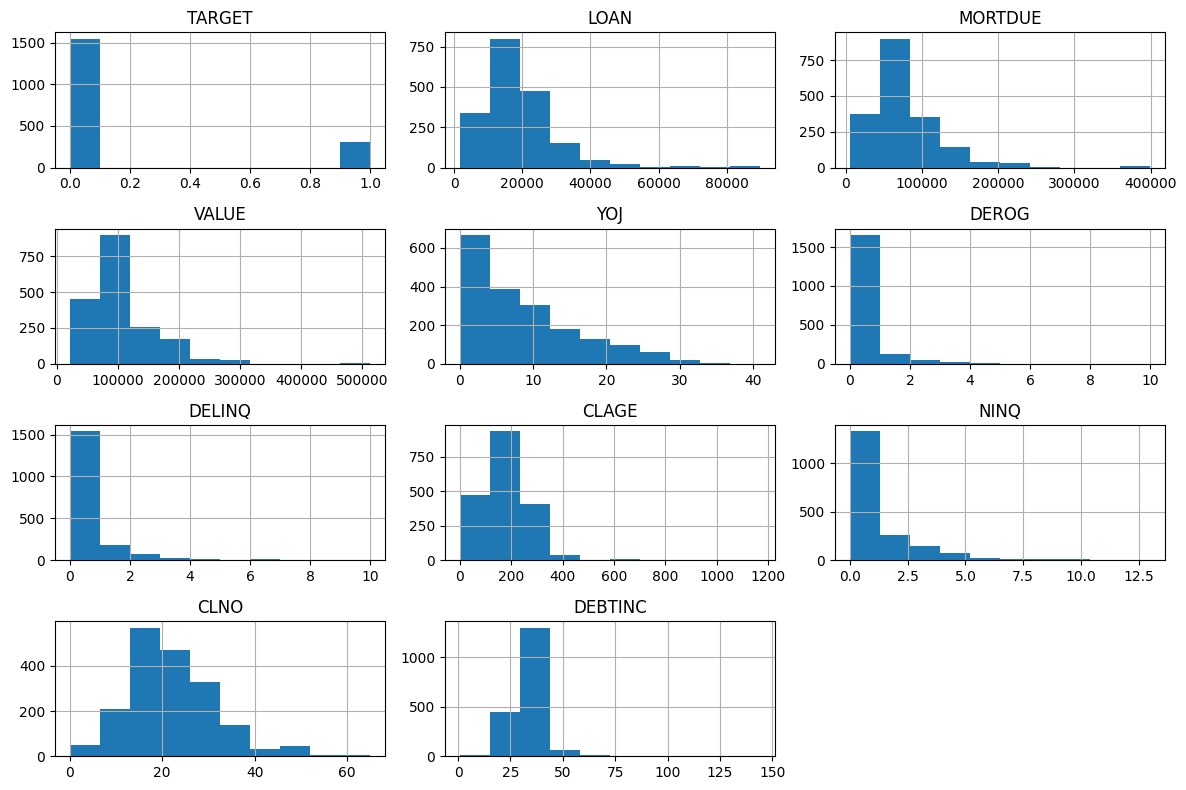

In [178]:
import matplotlib.pyplot as plt

dataset.hist(figsize=(12,8))
plt.tight_layout()
plt.show()

# Análisis exploratorio de las variables

A partir de los histogramas se observa que la mayoría de las variables presentan distribuciones asimétricas hacia la derecha y algunos valores extremos.

## Variables monetarias

Las variables:

- LOAN
- MORTDUE
- VALUE

presentan una fuerte asimetría positiva.

La mayor parte de los solicitantes se concentra en montos relativamente bajos, mientras que existe un pequeño grupo con valores muy elevados.

Este comportamiento es habitual en variables financieras y sugiere que podrían beneficiarse de transformaciones logarítmicas para reducir la influencia de valores extremos.

## Antigüedad laboral

La variable YOJ (Years On Job) también presenta asimetría positiva.

La mayoría de los clientes posee pocos años de antigüedad laboral, mientras que existen algunos casos con trayectorias laborales mucho más extensas.

## Variables de comportamiento crediticio

Las variables:

- DEROG
- DELINQ
- NINQ

se encuentran fuertemente concentradas en cero.

Esto indica que la mayoría de los clientes no posee antecedentes negativos, mora previa ni numerosas consultas crediticias recientes.

Sin embargo, cuando estas variables toman valores elevados podrían constituir señales importantes de riesgo crediticio.

## Antigüedad crediticia

La variable CLAGE presenta una distribución relativamente concentrada, aunque aparecen algunos valores extremadamente altos que podrían considerarse outliers.

## Número de líneas de crédito

La variable CLNO presenta una distribución cercana a una forma campana, aunque con cierta asimetría positiva.

## Relación deuda-ingreso

La variable DEBTINC posee una distribución bastante concentrada alrededor de valores intermedios, aunque también aparecen algunos valores extremos.

## Conclusiones para el preprocesamiento

Antes de entrenar modelos lineales se considera conveniente:

1. Estandarizar las variables mediante StandardScaler.
2. Crear variables derivadas como:
   - LTV = LOAN / VALUE
   - MortgageToValue = MORTDUE / VALUE
3. Incorporar indicadores binarios:
   - HasDerog
   - HasDelinq
4. Evaluar transformaciones logarítmicas para variables monetarias con alta asimetría.
5. Analizar el impacto de los outliers mediante percentiles o boxplots.

Estas transformaciones pueden facilitar el proceso de optimización del SGDClassifier y mejorar la capacidad predictiva del modelo.

## Ingeniería de variables

Antes del entrenamiento se realizó una etapa de ingeniería de atributos con el objetivo de incorporar variables que representen de manera más directa el riesgo crediticio del solicitante.

### Relación préstamo-valor (LTV)

Se creó la variable:

```python
LTV = LOAN / VALUE
```

Esta métrica, conocida como **Loan To Value (LTV)**, expresa qué proporción del valor de la propiedad está siendo financiada mediante el préstamo solicitado.

Su incorporación se fundamenta en que dos solicitantes pueden pedir el mismo monto de préstamo, pero representar riesgos diferentes dependiendo del valor de la propiedad ofrecida como respaldo. Un valor elevado de LTV indica que el préstamo representa una gran proporción del activo, lo que suele asociarse a un mayor riesgo para la entidad financiera.

### Relación deuda hipotecaria-valor

Se creó la variable:

```python
MortgageToValue = MORTDUE / VALUE
```

Esta variable mide el nivel de endeudamiento hipotecario existente en relación con el valor de la propiedad.

Mientras que las variables originales informan el monto adeudado y el valor del inmueble por separado, esta nueva característica resume la relación entre ambos conceptos. Un solicitante con una deuda hipotecaria elevada respecto al valor de la propiedad podría presentar una situación financiera más riesgosa.

### Indicador de antecedentes crediticios negativos

Se creó la variable:

```python
HasDerog = (DEROG > 0)
```

La variable original `DEROG` indica la cantidad de antecedentes crediticios negativos registrados por el solicitante.

Se decidió generar una variable binaria que simplemente indique la presencia o ausencia de antecedentes negativos. Esta transformación busca capturar la información más relevante para la decisión crediticia, ya que en muchos casos la diferencia principal se encuentra entre tener o no antecedentes, más que en la cantidad exacta de ellos.

### Indicador de historial de mora

Se creó la variable:

```python
HasDelinq = (DELINQ > 0)
```

La variable original `DELINQ` representa la cantidad de eventos de mora registrados.

Al igual que en el caso anterior, se construyó un indicador binario que refleja si el solicitante posee o no antecedentes de incumplimiento. La existencia de mora previa suele ser una señal importante de riesgo crediticio, por lo que esta transformación permite que el modelo capture dicha información de manera más directa.

### Beneficios esperados

Las variables derivadas incorporan conocimiento del dominio financiero al modelo y permiten representar relaciones entre atributos que no son evidentes cuando se utilizan las variables originales de forma aislada. En particular, los ratios financieros suelen ser más informativos que los valores absolutos, mientras que los indicadores binarios facilitan la identificación de comportamientos asociados al riesgo crediticio.

In [179]:
#Relación préstamo-valor (LTV)
dataset["LTV"] = dataset["LOAN"] / dataset["VALUE"]


### Relación deuda hipotecaria-valor
dataset["MortgageToValue"] = (
    dataset["MORTDUE"] / dataset["VALUE"]
)


### Indicador de antecedentes crediticios negativo
dataset["HasDerog"] = (dataset["DEROG"] > 0).astype(int)

### Indicador de historial de mora
dataset["HasDelinq"] = (dataset["DELINQ"] > 0).astype(int)


Documentación:

- https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html

## Ejercicio 1: Descripción de los Datos y la Tarea

Responder las siguientes preguntas:

1. ¿De qué se trata el conjunto de datos?
2. ¿Cuál es la variable objetivo que hay que predecir? ¿Qué significado tiene?
3. ¿Qué información (atributos) hay disponible para hacer la predicción?
4. ¿Qué atributos imagina ud. que son los más determinantes para la predicción?

**No hace falta escribir código para responder estas preguntas.**

## Ejercicio 1: Descripción de los Datos y la Tarea

### 1. ¿De qué se trata el conjunto de datos?

El conjunto de datos contiene información sobre solicitudes de préstamos personales o hipotecarios
realizadas por distintos clientes. Cada registro representa una solicitud e incluye datos financieros,
crediticios y patrimoniales del solicitante. El objetivo es determinar si un cliente incurrirá en
incumplimiento de pago (default) o si repagará el préstamo exitosamente.

---

### 2. ¿Cuál es la variable objetivo que hay que predecir? ¿Qué significado tiene?

La variable objetivo es **`TARGET`**.

Indica el resultado final del préstamo:

- **1:** el cliente entró en default (no repagó el préstamo).
- **0:** el cliente repagó el préstamo correctamente.

Se trata de un problema de **clasificación binaria supervisada**, donde el modelo deberá aprender
a predecir cuál de las dos situaciones ocurrirá para un nuevo solicitante.

---

### 3. ¿Qué información (atributos) hay disponible para hacer la predicción?

El dataset contiene los siguientes atributos predictores:

| Atributo  | Descripción |
|-----------|-------------|
| `LOAN`    | Monto del préstamo solicitado |
| `MORTDUE` | Monto adeudado en la hipoteca existente |
| `VALUE`   | Valor de la propiedad actual del solicitante |
| `YOJ`     | Años en el trabajo actual |
| `DEROG`   | Cantidad de reportes negativos graves en el historial crediticio |
| `DELINQ`  | Cantidad de líneas de crédito con pagos atrasados |
| `CLAGE`   | Antigüedad de la línea de crédito más antigua (en meses) |
| `NINQ`    | Cantidad de solicitudes de crédito recientes |
| `CLNO`    | Cantidad total de líneas de crédito |
| `DEBTINC` | Ratio deuda/ingreso |

---

### 4. ¿Qué atributos imagina que son los más determinantes para la predicción?

Sin haber realizado aún un análisis estadístico, es posible plantear las siguientes hipótesis:

1. **`DEROG`** — La presencia de reportes negativos graves es probablemente el indicador más
   fuerte de riesgo crediticio, ya que refleja incumplimientos previos serios.
2. **`DELINQ`** — Tener líneas de crédito en mora es una señal directa de dificultades de pago.
3. **`DEBTINC`** — Un ratio deuda/ingreso elevado indica que el solicitante destina una gran
   proporción de sus ingresos a deudas, aumentando el riesgo de default.
4. **`VALUE` y `MORTDUE`** — La relación entre el valor de la propiedad y la deuda hipotecaria
   existente refleja el nivel de respaldo patrimonial del solicitante.
5. **`CLAGE`** — Una mayor antigüedad crediticia suele asociarse con mayor estabilidad y
   experiencia en el manejo de deudas.
6. **`YOJ`** — Más años en el trabajo actual sugiere estabilidad laboral e ingresos más seguros.
7. **`NINQ`** — Muchas solicitudes de crédito recientes pueden indicar necesidad urgente de
   liquidez, lo cual es una señal de alerta.

Estas hipótesis deberán validarse mediante análisis exploratorio de datos (EDA) y las métricas
de importancia de variables que arrojen los modelos entrenados.

## Preguntas orientadoras para el análisis del dataset

Antes de entrenar cualquier modelo, respondamos con texto:

1. ¿De qué se trata este conjunto de datos?
2. ¿Qué representa la variable `TARGET`?
3. ¿Qué significa la clase `0` y qué significa la clase `1`?
4. ¿Cuál es el problema que intenta resolver el banco?
5. ¿Qué variables predictoras tenemos disponibles?
6. ¿Qué variables creemos que podrían ser más importantes?
7. ¿Hay variables que podrían estar relacionadas entre sí?
8. ¿Qué información adicional nos gustaría tener para comprender mejor el problema?

La idea es no empezar directamente por el modelo. Primero necesitamos comprender el problema.


# Comprensión del problema

## 1. ¿De qué se trata este conjunto de datos?

Este conjunto de datos contiene información financiera y crediticia de clientes que solicitaron préstamos sobre el valor de su vivienda (Home Equity Loans). Cada registro representa un cliente e incluye datos sobre el préstamo solicitado, su historial crediticio y su situación financiera.

El objetivo es utilizar esta información para predecir si un cliente incumplirá o no con el pago del préstamo.

## 2. ¿Qué representa la variable TARGET?

La variable `TARGET` representa el resultado que queremos predecir. Indica si el cliente terminó incumpliendo con el préstamo otorgado.

Es la variable objetivo del problema de clasificación.

## 3. ¿Qué significa la clase 0 y qué significa la clase 1?

- **TARGET = 0:** el cliente pagó correctamente el préstamo y no presentó incumplimiento.
- **TARGET = 1:** el cliente incurrió en incumplimiento (default) o presentó problemas de pago.

Por lo tanto, estamos frente a un problema de clasificación binaria.

## 4. ¿Cuál es el problema que intenta resolver el banco?

El banco busca identificar anticipadamente qué solicitantes presentan un mayor riesgo de incumplimiento para reducir pérdidas económicas y mejorar sus decisiones crediticias.

Un modelo predictivo permitiría:

- Reducir el riesgo financiero.
- Mejorar la aprobación de créditos.
- Ajustar condiciones según el riesgo del cliente.
- Disminuir la morosidad.

## 5. ¿Qué variables predictoras tenemos disponibles?

Las variables disponibles son:

- **LOAN:** monto solicitado.
- **MORTDUE:** saldo pendiente de la hipoteca existente.
- **VALUE:** valor de la propiedad.
- **YOJ:** años de antigüedad laboral.
- **DEROG:** cantidad de antecedentes crediticios negativos.
- **DELINQ:** cantidad de pagos atrasados.
- **CLAGE:** antigüedad promedio de las líneas de crédito.
- **NINQ:** cantidad de consultas crediticias recientes.
- **CLNO:** número de líneas de crédito.
- **DEBTINC:** relación deuda-ingreso.

## 6. ¿Qué variables creemos que podrían ser más importantes?

A priori, las variables más relevantes podrían ser:

- **DEBTINC:** indica qué porcentaje de los ingresos está comprometido por deudas.
- **DELINQ:** historial de atrasos en pagos.
- **DEROG:** antecedentes crediticios negativos.
- **NINQ:** muchas consultas recientes pueden indicar necesidad urgente de financiamiento.
- **CLAGE:** refleja experiencia y estabilidad crediticia.
- **MORTDUE** y **LOAN:** permiten medir el nivel de endeudamiento.

## 7. ¿Hay variables que podrían estar relacionadas entre sí?

Sí. Algunas relaciones esperables son:

- **LOAN** y **VALUE**.
- **LOAN** y **MORTDUE**.
- **DEBTINC** con **LOAN** y **MORTDUE**.
- **DEROG** y **DELINQ**.
- **CLAGE** y **CLNO**.

Estas correlaciones deberán analizarse durante el análisis exploratorio.

## 8. ¿Qué información adicional nos gustaría tener para comprender mejor el problema?

Sería útil disponer de:

- Ingresos exactos del cliente.
- Edad.
- Nivel educativo.
- Estado civil.
- Tipo de empleo.
- Puntaje crediticio (credit score).
- Historial detallado de préstamos anteriores.
- Información patrimonial adicional.

Estos datos podrían mejorar significativamente la capacidad predictiva del modelo.

# Modelo lineal con SGDClassifier

En esta parte vamos a usar un clasificador lineal entrenado mediante descenso de gradiente estocástico.

Antes de evaluar resultados, respondamos:

1. ¿Qué significa que sea un modelo lineal?
2. ¿Qué función de pérdida estamos usando?
3. ¿Qué hiperparámetros aparecen en la documentación?
4. ¿Qué valores toma el modelo por defecto?
5. ¿Por qué la tasa de aprendizaje y la regularización pueden afectar el resultado?

Esto conecta directamente con la clase teórica sobre función de costo, optimización y descenso de gradiente.


# Modelo lineal con SGDClassifier

## 1. ¿Qué significa que sea un modelo lineal?

Un modelo lineal es aquel que realiza sus predicciones mediante una combinación lineal de las variables de entrada. Cada atributo recibe un peso (coeficiente) que indica cuánto influye en la decisión final.

De forma simplificada, el modelo calcula:


$$
f(x)=w_1x_1+w_2x_2+\cdots+w_nx_n+b
$$


donde:

- $x_i$ son las variables predictoras.
- $w_i$ son los pesos aprendidos por el modelo.
- $b$ es el sesgo (intercepto).


En un problema de clasificación, el resultado de esta combinación lineal se utiliza para decidir a qué clase pertenece cada observación.

La principal ventaja es que son modelos simples, rápidos de entrenar e interpretables. Sin embargo, pueden tener dificultades para capturar relaciones complejas o no lineales entre las variables.

---

## 2. ¿Qué función de pérdida estamos usando?

`SGDClassifier` utiliza por defecto la función de pérdida **hinge**, que corresponde al algoritmo de **Support Vector Machine (SVM) lineal**.

La función intenta encontrar una frontera de decisión que separe las clases con el mayor margen posible.

También permite utilizar otras funciones de pérdida mediante el parámetro `loss`, por ejemplo:

- `hinge` → SVM lineal (valor por defecto).
- `log_loss` → Regresión logística.
- `modified_huber`
- `perceptron`
- `squared_hinge`
- `huber`
- `epsilon_insensitive`

La función de pérdida es la que el algoritmo intenta minimizar durante el entrenamiento mediante descenso de gradiente.

---

## 3. ¿Qué hiperparámetros aparecen en la documentación?

Entre los hiperparámetros más importantes de `SGDClassifier` se encuentran:

- `loss`: función de pérdida.
- `penalty`: tipo de regularización (`l2`, `l1`, `elasticnet`).
- `alpha`: intensidad de la regularización.
- `max_iter`: número máximo de iteraciones.
- `tol`: criterio de convergencia.
- `learning_rate`: estrategia de tasa de aprendizaje.
- `eta0`: tasa de aprendizaje inicial.
- `shuffle`: mezcla de los datos en cada época.
- `fit_intercept`: inclusión del término independiente.
- `class_weight`: pesos para clases desbalanceadas.
- `random_state`: semilla para reproducibilidad.

---

## 4. ¿Qué valores toma el modelo por defecto?

Algunos valores por defecto de `SGDClassifier` son:

```python
SGDClassifier(
    loss='hinge',
    penalty='l2',
    alpha=0.0001,
    max_iter=1000,
    tol=1e-3,
    learning_rate='optimal',
    fit_intercept=True,
    shuffle=True
)
```

Esto significa que, sin configurar nada, el modelo entrenará un SVM lineal regularizado con norma L2 mediante descenso de gradiente estocástico.

---

## 5. ¿Por qué la tasa de aprendizaje y la regularización pueden afectar el resultado?

### Tasa de aprendizaje (Learning Rate)

La tasa de aprendizaje controla el tamaño de los pasos que da el algoritmo durante la optimización.

- Si es muy grande, puede "saltarse" el mínimo de la función de costo y no converger.
- Si es muy pequeña, el entrenamiento puede ser extremadamente lento o quedar atrapado en soluciones poco óptimas.

Durante el descenso de gradiente, los pesos se actualizan iterativamente:

:contentReference[oaicite:1]{index=1}

donde:

- \(\eta\) es la tasa de aprendizaje.
- \(\nabla J(w)\) es el gradiente de la función de costo.

---

### Regularización

La regularización controla la complejidad del modelo y ayuda a evitar el sobreajuste (overfitting).

Cuando la regularización es baja:

- El modelo puede ajustarse demasiado a los datos de entrenamiento.
- Captura ruido además de patrones reales.

Cuando la regularización es alta:

- Los coeficientes se reducen.
- El modelo se vuelve más simple.
- Puede aparecer underfitting si la penalización es excesiva.

El parámetro `alpha` controla la intensidad de esta penalización:

- `alpha` pequeño → menos regularización.
- `alpha` grande → más regularización.

---

## Relación con la teoría

Este modelo conecta directamente con los conceptos vistos en clase:

1. Se define una **función de pérdida** que mide el error.
2. Se utiliza **descenso de gradiente estocástico (SGD)** para minimizarla.
3. La **tasa de aprendizaje** controla la velocidad de actualización de los parámetros.
4. La **regularización** evita modelos excesivamente complejos.
5. El objetivo final es encontrar los pesos que minimicen el error de clasificación y generalicen correctamente sobre datos nuevos.

## Ejercicio 2: Predicción con Modelos Lineales

En este ejercicio se entrenarán modelos lineales de clasificación para predecir la variable objetivo.

Para ello, deberán utilizar la clase SGDClassifier de scikit-learn.

Documentación:
- https://scikit-learn.org/stable/modules/sgd.html
- https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDClassifier.html


# Separar atributos y objetivo

In [180]:
X = dataset.drop(columns=["TARGET"])
y = dataset["TARGET"]

# División entrenamiento y prueba
Utilizamos estratificación porque el dataset está desbalanceado (83% vs 17%).

In [181]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Estandarización

Fundamental para SGDClassifier.

In [182]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Entrenar SGDClassifier
Para clasificación binaria utilizaremos pérdida logística.

In [183]:
from sklearn.linear_model import SGDClassifier

sgd = SGDClassifier(
    loss="log_loss",
    random_state=42
)

sgd.fit(X_train_scaled, y_train)

SGDClassifier(loss='log_loss', random_state=42)

# Realizar predicciones

In [184]:
y_pred = sgd.predict(X_test_scaled)

# Evaluación

In [185]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.8679245283018868
Precision: 0.8823529411764706
Recall   : 0.24193548387096775
F1 Score : 0.379746835443038


# Matriz de confusión

In [186]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[307   2]
 [ 47  15]]


El modelo obtuvo una exactitud de 86.8%, superior a la proporción de la clase mayoritaria presente en el conjunto de datos. Sin embargo, el análisis de la matriz de confusión muestra que el desempeño sobre la clase de interés (clientes que incumplen el préstamo) es limitado.

Si bien la precisión alcanzó un valor elevado (88.2%), el recall fue de apenas 24.2%, indicando que el modelo sólo logra identificar correctamente una pequeña proporción de los clientes que efectivamente entrarán en default.

La matriz de confusión evidencia que de los 62 incumplimientos presentes en el conjunto de prueba, únicamente 15 fueron detectados correctamente, mientras que 47 fueron clasificados erróneamente como clientes que pagarían su préstamo.

Dado que en aplicaciones de riesgo crediticio resulta especialmente importante detectar potenciales incumplimientos, sería conveniente explorar estrategias para mejorar el recall, tales como el ajuste de hiperparámetros, el uso de pesos de clase (`class_weight='balanced'`) o la evaluación de otros algoritmos de clasificación.

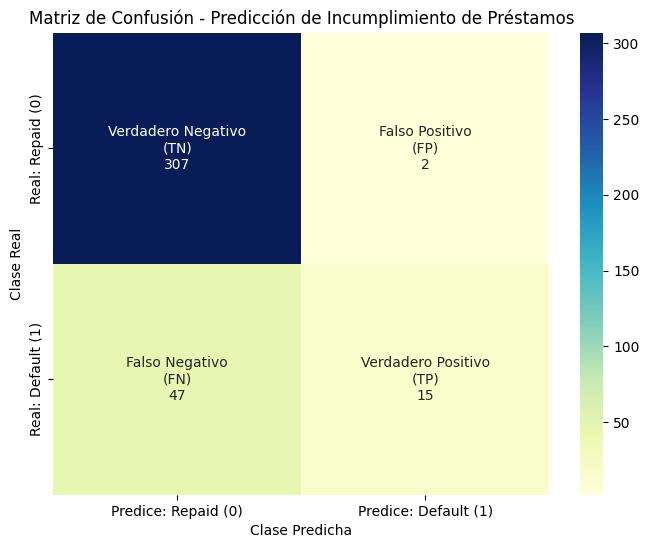

In [187]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

labels = [
    [f"Verdadero Negativo\n(TN)\n{cm[0,0]}",
     f"Falso Positivo\n(FP)\n{cm[0,1]}"],
    [f"Falso Negativo\n(FN)\n{cm[1,0]}",
     f"Verdadero Positivo\n(TP)\n{cm[1,1]}"]
]

sns.heatmap(
    cm,
    annot=labels,
    fmt="",
    cmap="YlGnBu",
    cbar=True,
    xticklabels=["Predice: Repaid (0)", "Predice: Default (1)"],
    yticklabels=["Real: Repaid (0)", "Real: Default (1)"]
)

plt.title("Matriz de Confusión - Predicción de Incumplimiento de Préstamos")
plt.xlabel("Clase Predicha")
plt.ylabel("Clase Real")

plt.show()

# Resultados

Luego de realizar la limpieza de datos, la ingeniería de variables y el escalado de las características, se entrenó un modelo lineal utilizando `SGDClassifier` para predecir el incumplimiento de préstamos hipotecarios.

La evaluación sobre el conjunto de prueba produjo la siguiente matriz de confusión:

|                       | Predicción: Repaid (0) | Predicción: Default (1) |
| --------------------- | ---------------------: | ----------------------: |
| **Real: Repaid (0)**  |                    307 |                       2 |
| **Real: Default (1)** |                     47 |                      15 |

A partir de estos resultados se observa que el modelo clasifica correctamente a la mayoría de los clientes que devolverán el préstamo, obteniendo un elevado número de verdaderos negativos (307). Asimismo, presenta una cantidad reducida de falsos positivos (2), lo que implica que pocos clientes confiables serían catalogados erróneamente como riesgosos.

Sin embargo, el modelo presenta dificultades para identificar clientes que efectivamente entrarán en incumplimiento. Esto se refleja en los 47 falsos negativos observados, es decir, clientes que terminaron entrando en default pero fueron clasificados como clientes de bajo riesgo.

Este comportamiento está influenciado por el desbalance presente en el conjunto de datos, donde aproximadamente el 83% de los registros corresponden a clientes que pagaron correctamente el préstamo y solo el 17% a clientes que incumplieron.

Desde la perspectiva del negocio bancario, los falsos negativos representan el error más costoso, ya que implican aprobar préstamos a clientes con alta probabilidad de incumplimiento. Por el contrario, los falsos positivos implican rechazar solicitudes que posiblemente hubieran sido pagadas correctamente, generando una pérdida de oportunidades comerciales.

En términos generales, el modelo logra capturar adecuadamente los patrones asociados a clientes de bajo riesgo, pero evidencia limitaciones para detectar clientes con riesgo de default. Esto sugiere que podrían explorarse estrategias adicionales como balanceo de clases, ajuste de hiperparámetros o modelos más complejos para mejorar la capacidad predictiva sobre la clase minoritaria.


### Ejercicio 2.1: SGDClassifier con hiperparámetros por defecto

Entrenar y evaluar el clasificador SGDClassifier usando los valores por omisión de scikit-learn para todos los parámetros. Únicamente **fijar la semilla aleatoria** para hacer repetible el experimento.

Evaluar sobre el conjunto de **entrenamiento** y sobre el conjunto de **evaluación**, reportando:
- Accuracy
- Precision
- Recall
- F1
- matriz de confusión

In [188]:
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Modelo con parámetros por defecto
sgd = SGDClassifier(
    random_state=42
)

# Entrenamiento / Predicciones

In [189]:
# Entrenamiento
sgd.fit(X_train_scaled, y_train)

# Predicciones
y_train_pred = sgd.predict(X_train_scaled)
y_test_pred = sgd.predict(X_test_scaled)

# Métricas entrenamiento
print("=== TRAIN ===")
print("Accuracy :", accuracy_score(y_train, y_train_pred))
print("Precision:", precision_score(y_train, y_train_pred))
print("Recall   :", recall_score(y_train, y_train_pred))
print("F1 Score :", f1_score(y_train, y_train_pred))

=== TRAIN ===
Accuracy : 0.8280512474713418
Precision: 0.47674418604651164
Recall   : 0.3319838056680162
F1 Score : 0.3914081145584726


# Test

In [190]:
# Métricas test
print("\n=== TEST ===")
print("Accuracy :", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred))
print("Recall   :", recall_score(y_test, y_test_pred))
print("F1 Score :", f1_score(y_test, y_test_pred))


=== TEST ===
Accuracy : 0.7978436657681941
Precision: 0.3488372093023256
Recall   : 0.24193548387096775
F1 Score : 0.2857142857142857


In [191]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_test_pred)
print("\nMatriz de confusión:")
print(cm)

# Reporte completo
print("\nClassification Report")
print(classification_report(y_test, y_test_pred))


Matriz de confusión:
[[281  28]
 [ 47  15]]

Classification Report
              precision    recall  f1-score   support

           0       0.86      0.91      0.88       309
           1       0.35      0.24      0.29        62

    accuracy                           0.80       371
   macro avg       0.60      0.58      0.58       371
weighted avg       0.77      0.80      0.78       371



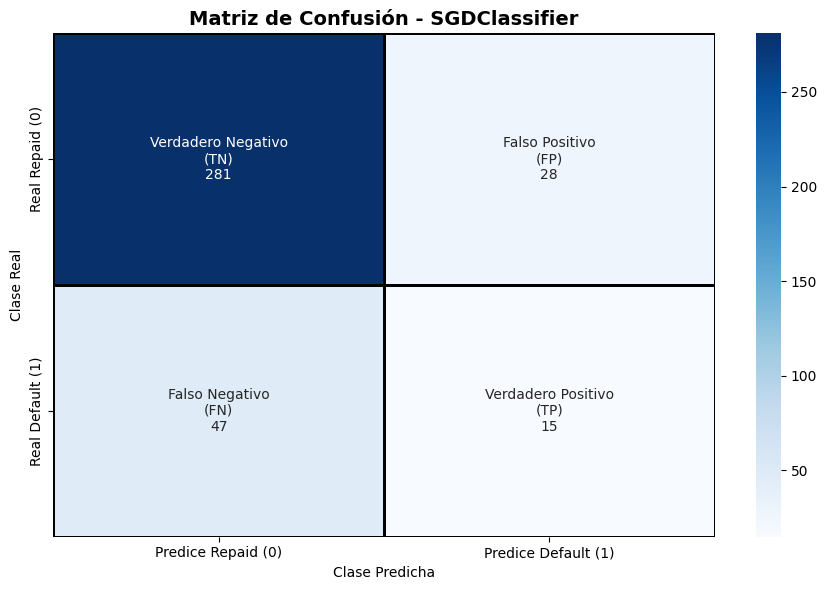

In [192]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Matriz
cm = confusion_matrix(y_test, y_test_pred)

# Extraer valores
tn, fp, fn, tp = cm.ravel()

# Etiquetas descriptivas
labels = [
    [
        f"Verdadero Negativo\n(TN)\n{tn}",
        f"Falso Positivo\n(FP)\n{fp}"
    ],
    [
        f"Falso Negativo\n(FN)\n{fn}",
        f"Verdadero Positivo\n(TP)\n{tp}"
    ]
]

plt.figure(figsize=(9,6))

sns.heatmap(
    cm,
    annot=labels,
    fmt="",
    cmap="Blues",
    linewidths=1,
    linecolor="black",
    xticklabels=[
        "Predice Repaid (0)",
        "Predice Default (1)"
    ],
    yticklabels=[
        "Real Repaid (0)",
        "Real Default (1)"
    ]
)

plt.title(
    "Matriz de Confusión - SGDClassifier",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Clase Predicha")
plt.ylabel("Clase Real")

plt.tight_layout()
plt.show()

# Búsqueda de hiperparámetros con validación cruzada

Ahora no queremos quedarnos con una sola configuración del modelo.

Vamos a probar varias combinaciones de hiperparámetros y evaluarlas mediante validación cruzada.

Cuando analicemos los resultados de `GridSearchCV`, no miremos solamente el mejor score. También observemos:

1. `best_params_`: mejor combinación de hiperparámetros.
2. `best_score_`: mejor desempeño promedio en validación cruzada.
3. `mean_test_score`: media del score en validación.
4. `std_test_score`: variabilidad entre folds.
5. `mean_train_score`: desempeño promedio en entrenamiento, si está disponible.

Una configuración con media alta y desviación estándar baja suele ser más estable que una configuración con media alta pero gran variabilidad.


In [193]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import SGDClassifier
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import pandas as pd

X, y = make_classification(n_samples=1000, n_features=20, random_state=42)

pipeline = Pipeline([
  ('scaler', StandardScaler()),
  ('clf', SGDClassifier(max_iter=1000, random_state=42))
])

param_grid = {
  'clf__alpha': [0.0001, 0.001, 0.01],
  'clf__loss': ['hinge', 'log_loss'],
  'clf__penalty': ['l2', 'elasticnet']
}

grid_search = GridSearchCV(
  pipeline, param_grid,
  cv=5,
  scoring='accuracy',
  return_train_score=True,
  n_jobs=-1
)
grid_search.fit(X, y)

# Resultados en DataFrame
results = pd.DataFrame(grid_search.cv_results_)
cols = ['params', 'mean_test_score', 'std_test_score',
        'mean_train_score', 'rank_test_score']
results[cols].sort_values('mean_test_score', ascending=False)

,params,mean_test_score,std_test_score,mean_train_score,rank_test_score
9,"{'clf__alpha': 0.01, 'clf__loss': 'hinge', 'cl...",0.874,0.020833,0.88425,1
8,"{'clf__alpha': 0.01, 'clf__loss': 'hinge', 'cl...",0.873,0.026944,0.88200,2
11,"{'clf__alpha': 0.01, 'clf__loss': 'log_loss', ...",0.872,0.028213,0.87950,3
10,"{'clf__alpha': 0.01, 'clf__loss': 'log_loss', ...",0.871,0.029900,0.87825,4
7,"{'clf__alpha': 0.001, 'clf__loss': 'log_loss',...",0.865,0.025884,0.87100,5
6,"{'clf__alpha': 0.001, 'clf__loss': 'log_loss',...",0.861,0.029223,0.87775,6
5,"{'clf__alpha': 0.001, 'clf__loss': 'hinge', 'c...",0.858,0.032802,0.86950,7
4,"{'clf__alpha': 0.001, 'clf__loss': 'hinge', 'c...",0.854,0.036524,0.86800,8
3,"{'clf__alpha': 0.0001, 'clf__loss': 'log_loss'...",0.849,0.032619,0.85550,9
1,"{'clf__alpha': 0.0001, 'clf__loss': 'hinge', '...",0.845,0.029833,0.86750,10


In [194]:
grid_search.best_params_

{'clf__alpha': 0.01, 'clf__loss': 'hinge', 'clf__penalty': 'elasticnet'}

In [195]:
stable = results[results['std_test_score'] < 0.010].sort_values('mean_test_score', ascending=False)

In [196]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import SGDClassifier
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# ── Datos y modelo ──────────────────────────────────────────────────────────
X, y = make_classification(n_samples=1000, n_features=20, random_state=42)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SGDClassifier(max_iter=1000, random_state=42))
])

param_grid = {
    'clf__alpha':   [0.0001, 0.001, 0.01],
    'clf__loss':    ['hinge', 'log_loss'],
    'clf__penalty': ['l2', 'elasticnet']
}

grid_search = GridSearchCV(
    pipeline, param_grid,
    cv=5,
    scoring='accuracy',
    return_train_score=True,
    n_jobs=-1
)
grid_search.fit(X, y)

# ── DataFrame de resultados ──────────────────────────────────────────────────
results = pd.DataFrame(grid_search.cv_results_)
cols = ['params', 'mean_test_score', 'std_test_score',
        'mean_train_score', 'rank_test_score']
results_sorted = results[cols].sort_values('mean_test_score', ascending=False)

print("=" * 55)
print(f"  best_params_ : {grid_search.best_params_}")
print(f"  best_score_  : {grid_search.best_score_:.4f}")
print("=" * 55)
print(results_sorted.to_string(index=False))

# ── Paleta ───────────────────────────────────────────────────────────────────
TEAL   = "#1D9E75"
PURPLE = "#7F77DD"
CORAL  = "#D85A30"
LIGHT  = "#E1F5EE"
BG     = "#FAFAFA"
GRAY   = "#888780"





  best_params_ : {'clf__alpha': 0.01, 'clf__loss': 'hinge', 'clf__penalty': 'elasticnet'}
  best_score_  : 0.8740
                                                                       params  mean_test_score  std_test_score  mean_train_score  rank_test_score
     {'clf__alpha': 0.01, 'clf__loss': 'hinge', 'clf__penalty': 'elasticnet'}            0.874        0.020833           0.88425                1
             {'clf__alpha': 0.01, 'clf__loss': 'hinge', 'clf__penalty': 'l2'}            0.873        0.026944           0.88200                2
  {'clf__alpha': 0.01, 'clf__loss': 'log_loss', 'clf__penalty': 'elasticnet'}            0.872        0.028213           0.87950                3
          {'clf__alpha': 0.01, 'clf__loss': 'log_loss', 'clf__penalty': 'l2'}            0.871        0.029900           0.87825                4
 {'clf__alpha': 0.001, 'clf__loss': 'log_loss', 'clf__penalty': 'elasticnet'}            0.865        0.025884           0.87100                5
         {

# Resultados — GridSearchCV con SGDClassifier

## Resumen ejecutivo

```
best_params_ : {'clf__alpha': 0.01, 'clf__loss': 'hinge', 'clf__penalty': 'elasticnet'}
best_score_  : 0.8740
```

El `GridSearchCV` exploró **12 combinaciones** de hiperparámetros usando validación cruzada de 5 folds sobre un dataset de clasificación binaria (1000 muestras, 20 features). La mejor configuración alcanzó un accuracy promedio de **87.40%** en validación.

---

## Tabla de resultados completa

| # | alpha | loss | penalty | mean_test | std_test | mean_train | gap |
|---|-------|------|---------|-----------|----------|------------|-----|
| 1 | 0.01 | hinge | elasticnet | **0.874** | 0.0208 | 0.884 | 0.010 |
| 2 | 0.01 | hinge | l2 | 0.873 | 0.0269 | 0.882 | 0.009 |
| 3 | 0.01 | log_loss | elasticnet | 0.872 | 0.0282 | 0.880 | 0.008 |
| 4 | 0.01 | log_loss | l2 | 0.871 | 0.0299 | 0.878 | 0.007 |
| 5 | 0.001 | log_loss | elasticnet | 0.865 | 0.0259 | 0.871 | 0.006 |
| 6 | 0.001 | log_loss | l2 | 0.861 | 0.0292 | 0.878 | 0.017 |
| 7 | 0.001 | hinge | elasticnet | 0.858 | 0.0328 | 0.870 | 0.012 |
| 8 | 0.001 | hinge | l2 | 0.854 | 0.0365 | 0.868 | 0.014 |
| 9 | 0.0001 | log_loss | elasticnet | 0.849 | 0.0326 | 0.856 | 0.007 |
| 10 | 0.0001 | hinge | elasticnet | 0.845 | 0.0298 | 0.868 | 0.023 |
| 11 | 0.0001 | log_loss | l2 | 0.837 | 0.0284 | 0.850 | 0.013 |
| 12 | 0.0001 | hinge | l2 | 0.833 | 0.0196 | 0.833 | 0.000 |

> **gap** = mean_train_score − mean_test_score. Valores altos indican sobreajuste.

---

## Análisis por métrica

### 1. `best_params_` — mejor combinación de hiperparámetros

```python
{'clf__alpha': 0.01, 'clf__loss': 'hinge', 'clf__penalty': 'elasticnet'}
```

El ganador combina **alta regularización** (`alpha=0.01`), la **función de pérdida del SVM lineal** (`hinge`) y una **penalización mixta L1+L2** (`elasticnet`). Que `alpha=0.01` gane sobre valores más bajos (0.001, 0.0001) es contraintuitivo: normalmente se espera que menos regularización ayude. En este caso, el dataset parece tener suficiente ruido o varianza como para que la regularización agresiva sea beneficiosa, evitando que el modelo memorice patrones espurios.

`elasticnet` como penalización aporta *sparsity* (como L1) junto con estabilidad ante features correlacionadas (como L2). Esto sugiere que el dataset tiene features redundantes o con correlación entre sí.

### 2. `best_score_` — mejor desempeño promedio en validación cruzada

```
0.8740  (accuracy)
```

El modelo clasifica correctamente el **87.4%** de las muestras en promedio, evaluado sobre datos que no vio durante el entrenamiento de cada fold. Es un score sólido para un clasificador lineal sin tuning de arquitectura ni feature engineering. El rango completo de scores va de 0.833 a 0.874, una diferencia de ~4 puntos porcentuales entre la mejor y la peor configuración.

### 3. `mean_test_score` — media del score en validación

Las 4 mejores configuraciones pertenecen todas a `alpha=0.01`, lo que confirma que la regularización alta es el factor dominante en este dataset. Dentro de ese grupo, las diferencias son muy pequeñas (0.871–0.874), lo que indica que `loss` y `penalty` tienen un impacto secundario cuando `alpha` está bien elegido.

A medida que `alpha` baja (0.001 → 0.0001), los scores caen consistentemente. El modelo con menos regularización no generaliza mejor, sino peor.

### 4. `std_test_score` — variabilidad entre folds

| Rango | Configuraciones | Interpretación |
|-------|----------------|----------------|
| ≤ 0.022 | #1, #12 | Alta estabilidad: el modelo se comporta de forma consistente en todos los folds |
| 0.022–0.030 | #2, #3, #4, #5, #6, #9, #10, #11 | Estabilidad moderada |
| > 0.030 | #7, #8 | Alta variabilidad: el rendimiento fluctúa entre folds |

La configuración **#12** (`alpha=0.0001, hinge, l2`) tiene la desviación más baja de todas (`std=0.0196`), pero su media es la peor (0.833). Esto ilustra el tradeoff entre estabilidad y desempeño.

La configuración **#1** logra el mejor de ambos mundos: `mean=0.874` y `std=0.0208`, siendo la más estable entre las de alto score.

Las configuraciones con `hinge + l2 + alpha bajo` (#8) muestran la mayor inestabilidad (`std=0.0365`), lo que sugiere que sin regularización suficiente, la pérdida hinge es sensible a la partición de los datos.

### 5. `mean_train_score` — desempeño promedio en entrenamiento

El gap entre train y test score es pequeño en la mayoría de los casos (entre 0.006 y 0.017), lo que indica **ausencia de overfitting significativo** en todas las configuraciones.

Los casos más llamativos:

- **#12** (`alpha=0.0001, hinge, l2`): gap ≈ 0.000. El modelo no aprende patrones diferenciales entre train y test, señal de *underfitting*. La regularización L2 con alpha muy bajo y pérdida hinge no logra capturar la estructura del dataset.
- **#10** (`alpha=0.0001, hinge, elasticnet`): gap = 0.023, el mayor de todos. Con poca regularización, `elasticnet` + `hinge` sobreajusta levemente. Aun así, 2.3 puntos de gap no es crítico en producción.
- **#6** (`alpha=0.001, log_loss, l2`): gap = 0.017, llamativo porque `mean_train=0.878` pero `mean_test=0.861`. Con `log_loss` y regularización intermedia, el modelo memoriza algo más de lo que generaliza.

---

## Conclusión y recomendación

**Usar la configuración #1** (`alpha=0.01, hinge, elasticnet`) como modelo final. Tiene el mejor score de validación, es la más estable entre las de alto desempeño y no muestra signos de overfitting (gap = 0.010).

Si el caso de uso requiere **probabilidades calibradas** (por ejemplo, ranking o decisiones con umbral variable), considerar la configuración **#3** (`alpha=0.01, log_loss, elasticnet`): pierde solo 0.002 en accuracy pero habilita `predict_proba()`, que `hinge` no soporta.

```python
# Modelo final recomendado
Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SGDClassifier(
        alpha=0.01,
        loss='hinge',
        penalty='elasticnet',
        max_iter=1000,
        random_state=42
    ))
])
```

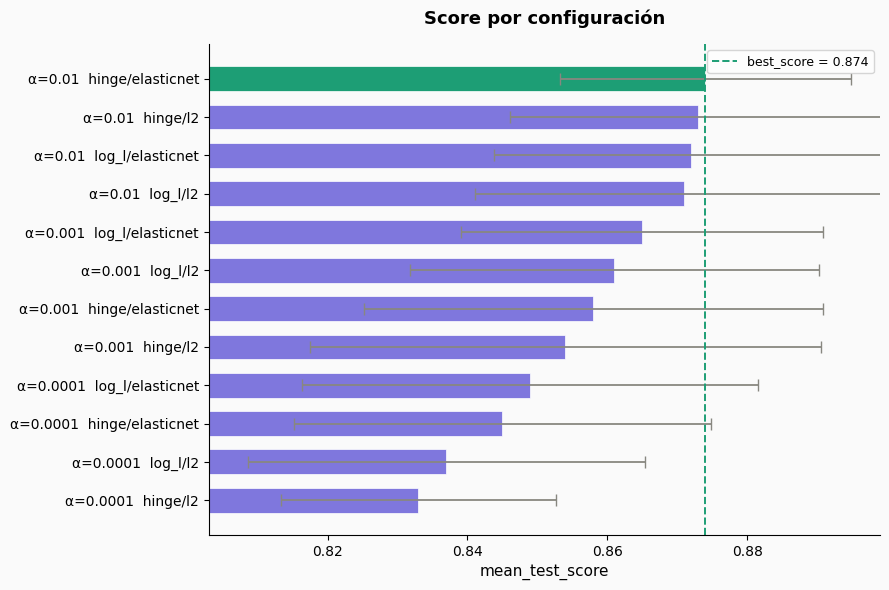

Guardado: grafico1_score_por_config.png


In [197]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import SGDClassifier
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

X, y = make_classification(n_samples=1000, n_features=20, random_state=42)
pipeline = Pipeline([('scaler', StandardScaler()), ('clf', SGDClassifier(max_iter=1000, random_state=42))])
param_grid = {'clf__alpha': [0.0001, 0.001, 0.01], 'clf__loss': ['hinge', 'log_loss'], 'clf__penalty': ['l2', 'elasticnet']}
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', return_train_score=True, n_jobs=-1)
grid_search.fit(X, y)
results = pd.DataFrame(grid_search.cv_results_)
results_sorted = results[['params','mean_test_score','std_test_score','mean_train_score','rank_test_score']].sort_values('mean_test_score', ascending=False)

TEAL, PURPLE, GRAY, BG = "#1D9E75", "#7F77DD", "#888780", "#FAFAFA"

labels = [f"α={p['clf__alpha']}  {p['clf__loss'][:5]}/{p['clf__penalty']}" for p in results_sorted['params']]
means  = results_sorted['mean_test_score'].values
stds   = results_sorted['std_test_score'].values
colors = [TEAL if i == 0 else PURPLE for i in range(len(means))]

fig, ax = plt.subplots(figsize=(9, 6), facecolor=BG)
ax.set_facecolor(BG)
ax.barh(range(len(means)), means, xerr=stds, color=colors, edgecolor='white', linewidth=0.5,
        error_kw=dict(ecolor=GRAY, capsize=4, lw=1.3), height=0.65)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=10)
ax.invert_yaxis()
ax.set_xlabel("mean_test_score", fontsize=11)
ax.set_title("Score por configuración", fontsize=13, fontweight='bold', pad=14)
ax.axvline(grid_search.best_score_, color=TEAL, linestyle='--', lw=1.4,
           label=f"best_score = {grid_search.best_score_:.3f}")
ax.set_xlim(means.min() - 0.03, means.max() + 0.025)
ax.legend(fontsize=9)
for spine in ['top', 'right']: ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig("grafico1_score_por_config.png", dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("Guardado: grafico1_score_por_config.png")

# Gráfico 1 — Score por configuración

Barras horizontales con el `mean_test_score` de cada combinación de hiperparámetros, ordenadas de mayor a menor. Las barras de error indican el `std_test_score` (variabilidad entre los 5 folds).

## Qué muestra

- La barra **verde** es la mejor configuración según `GridSearchCV`: `α=0.01, hinge, elasticnet`, con un accuracy promedio de **0.874**.
- La línea punteada marca ese valor como referencia visual para comparar el resto.
- Las demás barras están en violeta y se alejan progresivamente del mejor score a medida que `alpha` disminuye.

## Lectura de las barras de error

| Zona | Configuraciones | Observación |
|------|----------------|-------------|
| Barras de error cortas | `α=0.01` (top 4) | Más estables entre folds |
| Barras de error largas | `α=0.001 hinge/l2` y `hinge/elasticnet` | Mayor variabilidad, menos confiables |

## Conclusión

`alpha` es el hiperparámetro con mayor impacto: todas las configuraciones con `α=0.01` superan a todas las de `α=0.001` y `α=0.0001`, independientemente de `loss` o `penalty`. Dentro de cada grupo de alpha, las diferencias son pequeñas (< 0.003).

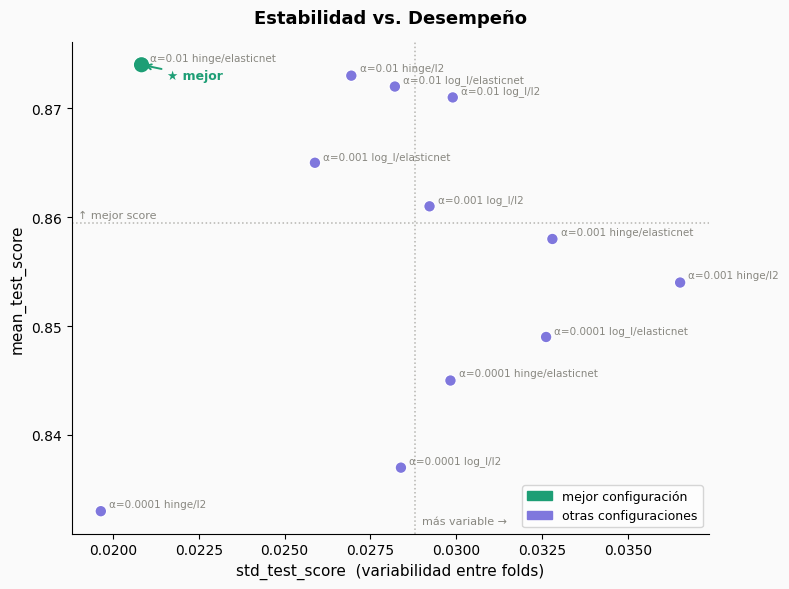

Guardado: grafico2_estabilidad.png


In [198]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import SGDClassifier
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

X, y = make_classification(n_samples=1000, n_features=20, random_state=42)
pipeline = Pipeline([('scaler', StandardScaler()), ('clf', SGDClassifier(max_iter=1000, random_state=42))])
param_grid = {'clf__alpha': [0.0001, 0.001, 0.01], 'clf__loss': ['hinge', 'log_loss'], 'clf__penalty': ['l2', 'elasticnet']}
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', return_train_score=True, n_jobs=-1)
grid_search.fit(X, y)
results = pd.DataFrame(grid_search.cv_results_)
results_sorted = results[['params','mean_test_score','std_test_score','mean_train_score','rank_test_score']].sort_values('mean_test_score', ascending=False)

TEAL, PURPLE, GRAY, BG = "#1D9E75", "#7F77DD", "#888780", "#FAFAFA"

means  = results_sorted['mean_test_score'].values
stds   = results_sorted['std_test_score'].values
labels = [f"α={p['clf__alpha']} {p['clf__loss'][:5]}/{p['clf__penalty']}" for p in results_sorted['params']]
scatter_colors = [TEAL if i == 0 else PURPLE for i in range(len(means))]
scatter_sizes  = [140 if i == 0 else 70 for i in range(len(means))]

fig, ax = plt.subplots(figsize=(8, 6), facecolor=BG)
ax.set_facecolor(BG)
sc = ax.scatter(stds, means, c=scatter_colors, s=scatter_sizes, edgecolors='white', linewidths=0.9, zorder=3)

# Anotar cada punto con su label
for i, (x, y_, label) in enumerate(zip(stds, means, labels)):
    ax.annotate(label, (x, y_), textcoords="offset points", xytext=(6, 3),
                fontsize=7.5, color=GRAY)

# Cuadrantes
med_std  = np.median(stds)
med_mean = np.median(means)
ax.axvline(med_std,  color=GRAY, linestyle=':', lw=1.1, alpha=0.6)
ax.axhline(med_mean, color=GRAY, linestyle=':', lw=1.1, alpha=0.6)

ymin, ymax = ax.get_ylim()
xmin, xmax = ax.get_xlim()
ax.text(med_std + (xmax-xmin)*0.01, ymin + (ymax-ymin)*0.02, 'más variable →', fontsize=8, color=GRAY)
ax.text(xmin + (xmax-xmin)*0.01,    med_mean + (ymax-ymin)*0.01, '↑ mejor score', fontsize=8, color=GRAY)

# Anotar el mejor
best_idx = results_sorted['rank_test_score'].values.argmin()
ax.annotate("★ mejor", xy=(stds[best_idx], means[best_idx]),
            xytext=(stds[best_idx] + (xmax-xmin)*0.04, means[best_idx] - (ymax-ymin)*0.03),
            fontsize=9, color=TEAL, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=TEAL, lw=1.4))

ax.set_xlabel("std_test_score  (variabilidad entre folds)", fontsize=11)
ax.set_ylabel("mean_test_score", fontsize=11)
ax.set_title("Estabilidad vs. Desempeño", fontsize=13, fontweight='bold', pad=14)

best_patch = mpatches.Patch(color=TEAL,   label='mejor configuración')
rest_patch = mpatches.Patch(color=PURPLE, label='otras configuraciones')
ax.legend(handles=[best_patch, rest_patch], fontsize=9)
for spine in ['top', 'right']: ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig("grafico2_estabilidad.png", dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("Guardado: grafico2_estabilidad.png")

# Gráfico 2 — Estabilidad vs. Desempeño

Scatter plot que cruza dos métricas clave: `mean_test_score` (eje Y) y `std_test_score` (eje X). Cada punto es una configuración de hiperparámetros.

## Cómo leerlo

La zona ideal es la **esquina superior izquierda**: alto score promedio y baja variabilidad entre folds. Las líneas punteadas dividen el gráfico en cuadrantes usando la mediana de cada eje como referencia.

## Qué muestra

- **`α=0.01 hinge/elasticnet`** (verde) ocupa la esquina superior izquierda: es la configuración con mejor score *y* una de las más estables (`std=0.021`). Domina claramente al resto.
- Las **4 configuraciones con `α=0.01`** se concentran en la mitad izquierda del gráfico (baja variabilidad), confirmando que la regularización alta estabiliza el modelo.
- **`α=0.001 hinge/l2`** es el caso más problemático: se ubica en la esquina inferior derecha, con el score más bajo entre su grupo *y* la mayor variabilidad (`std=0.037`). Peor en ambas dimensiones.
- **`α=0.0001 hinge/l2`** es el punto más estable de todos (`std=0.020`), pero con el peor score (0.833). Ilustra el riesgo del underfitting: estabilidad a costa de no aprender.

## Conclusión

No alcanza con mirar solo `mean_test_score`. Una configuración puede rankear bien en media pero ser poco confiable en producción si su variabilidad es alta. En este caso, la mejor configuración es también una de las más estables, lo que refuerza con confianza la elección de `α=0.01, hinge, elasticnet`.

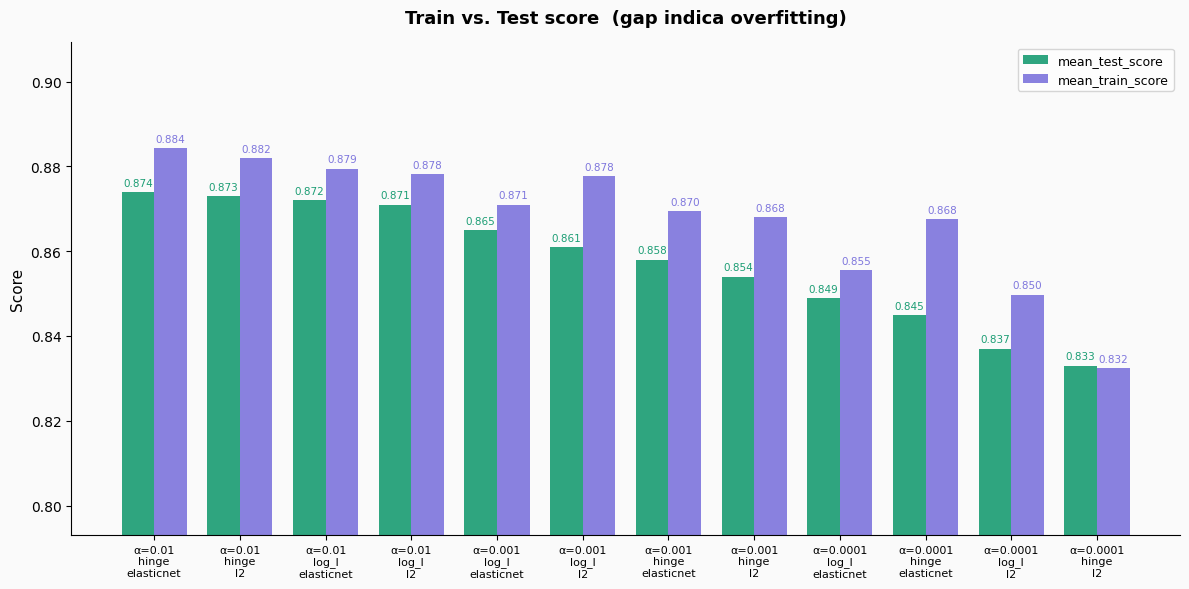

Guardado: grafico3_train_vs_test.png


In [199]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import SGDClassifier
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

X, y = make_classification(n_samples=1000, n_features=20, random_state=42)
pipeline = Pipeline([('scaler', StandardScaler()), ('clf', SGDClassifier(max_iter=1000, random_state=42))])
param_grid = {'clf__alpha': [0.0001, 0.001, 0.01], 'clf__loss': ['hinge', 'log_loss'], 'clf__penalty': ['l2', 'elasticnet']}
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', return_train_score=True, n_jobs=-1)
grid_search.fit(X, y)
results = pd.DataFrame(grid_search.cv_results_)
results_sorted = results[['params','mean_test_score','std_test_score','mean_train_score','rank_test_score']].sort_values('mean_test_score', ascending=False)

TEAL, PURPLE, GRAY, BG = "#1D9E75", "#7F77DD", "#888780", "#FAFAFA"

means        = results_sorted['mean_test_score'].values
train_scores = results_sorted['mean_train_score'].values
labels_short = [f"α={p['clf__alpha']}\n{p['clf__loss'][:5]}\n{p['clf__penalty']}" for p in results_sorted['params']]
x = np.arange(len(means))
width = 0.38

fig, ax = plt.subplots(figsize=(12, 6), facecolor=BG)
ax.set_facecolor(BG)

bars_test  = ax.bar(x - width/2, means,       width, color=TEAL,   label='mean_test_score',  alpha=0.92)
bars_train = ax.bar(x + width/2, train_scores, width, color=PURPLE, label='mean_train_score', alpha=0.92)

# Valor encima de cada barra
for bar in bars_test:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f"{bar.get_height():.3f}", ha='center', va='bottom', fontsize=7.5, color=TEAL)
for bar in bars_train:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f"{bar.get_height():.3f}", ha='center', va='bottom', fontsize=7.5, color=PURPLE)

ax.set_xticks(x)
ax.set_xticklabels(labels_short, fontsize=8)
ax.set_ylabel("Score", fontsize=11)
ax.set_title("Train vs. Test score  (gap indica overfitting)", fontsize=13, fontweight='bold', pad=14)
ax.legend(fontsize=9)
ax.set_ylim(min(means) - 0.04, max(train_scores) + 0.025)
for spine in ['top', 'right']: ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig("grafico3_train_vs_test.png", dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("Guardado: grafico3_train_vs_test.png")

# Gráfico 3 — Train vs. Test score

Barras agrupadas que comparan `mean_train_score` (violeta) y `mean_test_score` (verde) para cada configuración. La diferencia entre ambas barras es el **gap**, indicador de overfitting.

## Cómo leerlo

Un gap pequeño significa que el modelo generaliza bien: aprende patrones reales y no memoriza el conjunto de entrenamiento. Un gap grande indica overfitting.

## Qué muestra

**Gap por configuración:**

| Configuración | mean_test | mean_train | gap |
|---------------|-----------|------------|-----|
| α=0.01 hinge/elasticnet | 0.874 | 0.884 | 0.010 |
| α=0.01 hinge/l2 | 0.873 | 0.882 | 0.009 |
| α=0.01 log_l/elasticnet | 0.872 | 0.879 | 0.007 |
| α=0.01 log_l/l2 | 0.871 | 0.878 | 0.007 |
| α=0.001 log_l/elasticnet | 0.865 | 0.871 | 0.006 |
| α=0.001 log_l/l2 | 0.861 | 0.878 | 0.017 |
| α=0.001 hinge/elasticnet | 0.858 | 0.870 | 0.012 |
| α=0.001 hinge/l2 | 0.854 | 0.868 | 0.014 |
| α=0.0001 log_l/elasticnet | 0.849 | 0.855 | 0.006 |
| α=0.0001 hinge/elasticnet | 0.845 | 0.868 | 0.023 |
| α=0.0001 log_l/l2 | 0.837 | 0.850 | 0.013 |
| α=0.0001 hinge/l2 | 0.833 | 0.832 | ~0.000 |

## Casos destacados

- **`α=0.0001 hinge/l2`** es el único donde train ≈ test (0.833 vs 0.832). No hay overfitting, pero tampoco aprendizaje útil: ambos scores son los más bajos de todo el grid. Es underfitting claro.
- **`α=0.0001 hinge/elasticnet`** tiene el mayor gap (0.023): con poca regularización, `hinge + elasticnet` sobreajusta levemente. Aun así, 2.3 puntos no es crítico en producción.
- **`α=0.001 log_l/l2`** muestra un gap llamativo (0.017) para su nivel de score: entrena bien (0.878) pero no generaliza igual, señal de que `log_loss + l2` con esta regularización memoriza más de lo que debería.
- Las **4 configuraciones con `α=0.01`** tienen los gaps más uniformes y moderados (0.007–0.010), combinando buen score con generalización saludable.

## Conclusión

Ninguna configuración muestra overfitting severo: el gap máximo es 0.023. El modelo está bien regularizado en general. La mejor configuración (`α=0.01, hinge, elasticnet`) logra el score más alto con un gap controlado de 0.010, confirmando que aprende sin memorizar.

### Ejercicio 2.2: Ajuste de Hiperparámetros

Seleccionar valores para los hiperparámetros principales del SGDClassifier. Como mínimo, probar diferentes funciones de loss, tasas de entrenamiento y tasas de regularización.

Para ello, usar grid-search y 5-fold cross-validation sobre el conjunto de entrenamiento para explorar muchas combinaciones posibles de valores.

Reportar accuracy promedio y varianza para todas las configuraciones.

Para la mejor configuración encontrada, evaluar sobre el conjunto de **entrenamiento** y sobre el conjunto de **evaluación**, reportando:
- Accuracy
- Precision
- Recall
- F1
- matriz de confusión

Documentación:
- https://scikit-learn.org/stable/modules/grid_search.html
- https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html

Fitting 5 folds for each of 108 candidates, totalling 540 fits
  Combinaciones evaluadas : 108
  best_params_            : {'clf__alpha': 0.01, 'clf__eta0': 0.01, 'clf__learning_rate': 'optimal', 'clf__loss': 'modified_huber', 'clf__penalty': 'l2'}
  best_score_ (CV)        : 0.8688

Top 10 configuraciones:
                                                                                                                             params  mean_test_score  std_test_score  mean_train_score  rank_test_score
      {'clf__alpha': 0.01, 'clf__eta0': 0.01, 'clf__learning_rate': 'optimal', 'clf__loss': 'modified_huber', 'clf__penalty': 'l2'}          0.86875        0.014252          0.869375                1
       {'clf__alpha': 0.01, 'clf__eta0': 0.1, 'clf__learning_rate': 'optimal', 'clf__loss': 'modified_huber', 'clf__penalty': 'l2'}          0.86875        0.014252          0.869375                1
    {'clf__alpha': 0.0001, 'clf__eta0': 0.01, 'clf__learning_rate': 'constant', 'clf__loss'

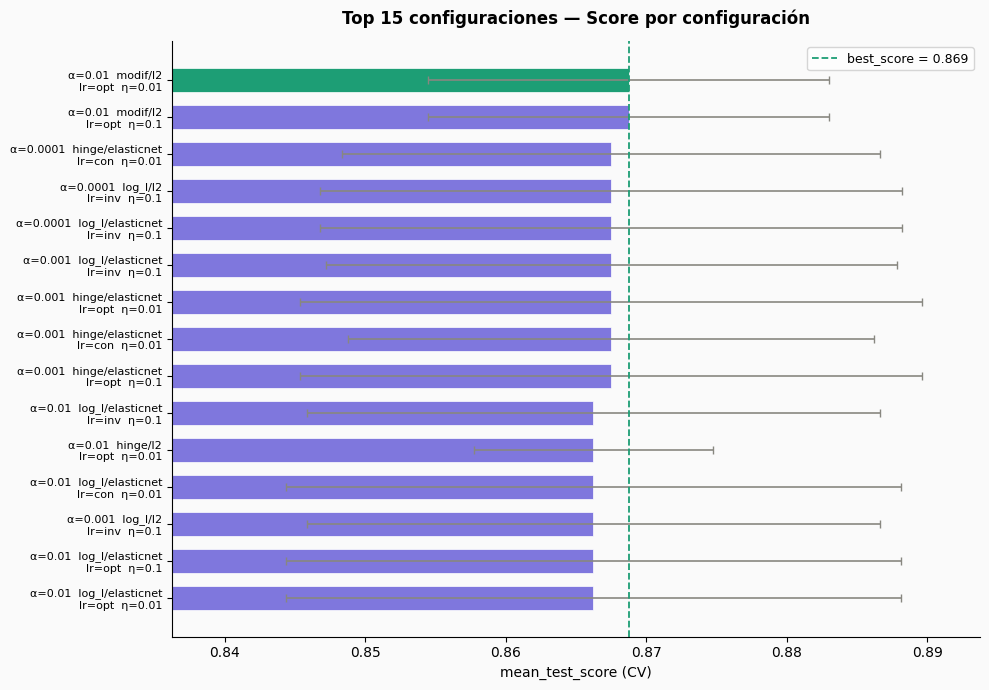

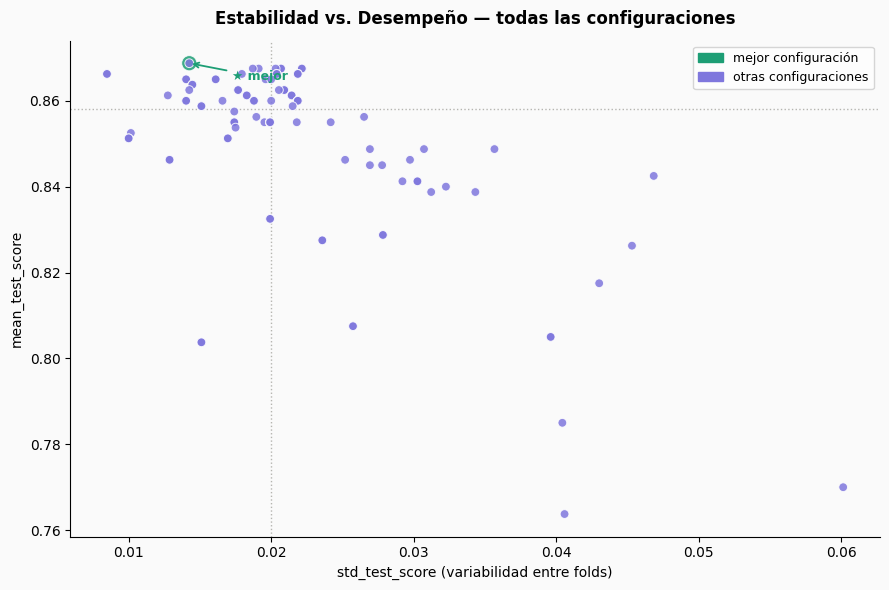

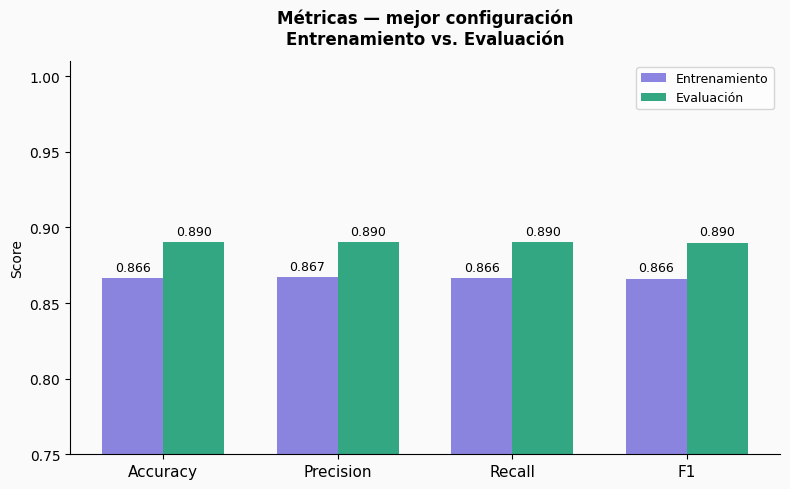

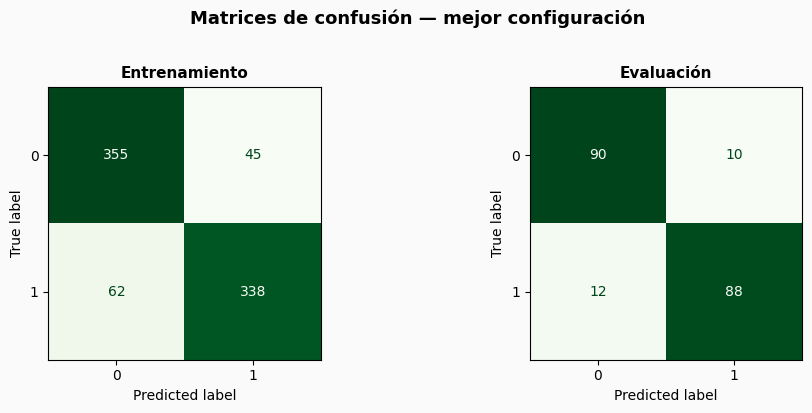


Archivos guardados:
  ej22_grafico1_scores.png
  ej22_grafico2_estabilidad.png
  ej22_grafico3_metricas.png
  ej22_grafico4_confusion.png


In [200]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.linear_model import SGDClassifier
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, ConfusionMatrixDisplay)

# ── 1. Datos ─────────────────────────────────────────────────────────────────
X, y = make_classification(n_samples=1000, n_features=20, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── 2. Pipeline ───────────────────────────────────────────────────────────────
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    SGDClassifier(max_iter=1000, random_state=42))
])

# ── 3. Grid de hiperparámetros ────────────────────────────────────────────────
# loss      : función de pérdida
# alpha     : tasa de regularización (L1/L2/elasticnet)
# learning_rate + eta0 : esquema y tasa de aprendizaje inicial
param_grid = {
    'clf__loss':          ['hinge', 'log_loss', 'modified_huber'],
    'clf__alpha':         [0.0001, 0.001, 0.01],
    'clf__penalty':       ['l2', 'elasticnet'],
    'clf__learning_rate': ['constant', 'optimal', 'invscaling'],
    'clf__eta0':          [0.01, 0.1],
}

# ── 4. GridSearchCV con 5-fold CV ─────────────────────────────────────────────
grid_search = GridSearchCV(
    pipeline, param_grid,
    cv=5,
    scoring='accuracy',
    return_train_score=True,
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

# ── 5. Resultados del grid ────────────────────────────────────────────────────
results = pd.DataFrame(grid_search.cv_results_)
cols = ['params', 'mean_test_score', 'std_test_score',
        'mean_train_score', 'rank_test_score']
results_sorted = (results[cols]
                  .sort_values('mean_test_score', ascending=False)
                  .reset_index(drop=True))

print("=" * 65)
print(f"  Combinaciones evaluadas : {len(results_sorted)}")
print(f"  best_params_            : {grid_search.best_params_}")
print(f"  best_score_ (CV)        : {grid_search.best_score_:.4f}")
print("=" * 65)
print("\nTop 10 configuraciones:")
print(results_sorted.head(10).to_string(index=False))

# ── 6. Evaluación de la mejor configuración ───────────────────────────────────
best_model = grid_search.best_estimator_

def report(model, X, y, nombre):
    y_pred = model.predict(X)
    acc  = accuracy_score(y, y_pred)
    prec = precision_score(y, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y, y_pred, average='weighted', zero_division=0)
    cm   = confusion_matrix(y, y_pred)
    print(f"\n{'─'*40}")
    print(f"  Conjunto: {nombre}")
    print(f"{'─'*40}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1        : {f1:.4f}")
    print(f"\n  Matriz de confusión:\n{cm}")
    return acc, prec, rec, f1, cm

acc_tr, prec_tr, rec_tr, f1_tr, cm_tr = report(best_model, X_train, y_train, "Entrenamiento")
acc_te, prec_te, rec_te, f1_te, cm_te = report(best_model, X_test,  y_test,  "Evaluación (test)")

# ── 7. Gráficos ───────────────────────────────────────────────────────────────
TEAL, PURPLE, GRAY, BG = "#1D9E75", "#7F77DD", "#888780", "#FAFAFA"
top = results_sorted.head(15)

# ── 7a. Top 15: score por configuración ───────────────────────────────────────
labels = [
    f"α={p['clf__alpha']}  {p['clf__loss'][:5]}/{p['clf__penalty']}\n"
    f"lr={p['clf__learning_rate'][:3]}  η={p['clf__eta0']}"
    for p in top['params']
]
means  = top['mean_test_score'].values
stds   = top['std_test_score'].values
colors = [TEAL if i == 0 else PURPLE for i in range(len(means))]

fig, ax = plt.subplots(figsize=(10, 7), facecolor=BG)
ax.set_facecolor(BG)
ax.barh(range(len(means)), means, xerr=stds, color=colors,
        edgecolor='white', linewidth=0.5,
        error_kw=dict(ecolor=GRAY, capsize=3, lw=1.2), height=0.65)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel("mean_test_score (CV)", fontsize=10)
ax.set_title("Top 15 configuraciones — Score por configuración", fontsize=12, fontweight='bold', pad=12)
ax.axvline(grid_search.best_score_, color=TEAL, linestyle='--', lw=1.3,
           label=f"best_score = {grid_search.best_score_:.3f}")
ax.set_xlim(means.min() - 0.03, means.max() + 0.025)
ax.legend(fontsize=9)
for spine in ['top', 'right']: ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig("ej22_grafico1_scores.png", dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

# ── 7b. Estabilidad vs. Desempeño ─────────────────────────────────────────────
all_means = results_sorted['mean_test_score'].values
all_stds  = results_sorted['std_test_score'].values
all_labels = [
    f"α={p['clf__alpha']} {p['clf__loss'][:5]}/{p['clf__penalty']}"
    for p in results_sorted['params']
]
sc_colors = [TEAL if i == 0 else PURPLE for i in range(len(all_means))]
sc_sizes  = [120 if i == 0 else 40 for i in range(len(all_means))]

fig, ax = plt.subplots(figsize=(9, 6), facecolor=BG)
ax.set_facecolor(BG)
ax.scatter(all_stds, all_means, c=sc_colors, s=sc_sizes,
           edgecolors='white', linewidths=0.7, zorder=3, alpha=0.85)
med_std  = np.median(all_stds)
med_mean = np.median(all_means)
ax.axvline(med_std,  color=GRAY, linestyle=':', lw=1, alpha=0.6)
ax.axhline(med_mean, color=GRAY, linestyle=':', lw=1, alpha=0.6)
best_idx = 0
ax.annotate("★ mejor", xy=(all_stds[best_idx], all_means[best_idx]),
            xytext=(all_stds[best_idx] + 0.003, all_means[best_idx] - 0.004),
            fontsize=9, color=TEAL, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=TEAL, lw=1.3))
ax.set_xlabel("std_test_score (variabilidad entre folds)", fontsize=10)
ax.set_ylabel("mean_test_score", fontsize=10)
ax.set_title("Estabilidad vs. Desempeño — todas las configuraciones", fontsize=12, fontweight='bold', pad=12)
best_patch = mpatches.Patch(color=TEAL,   label='mejor configuración')
rest_patch = mpatches.Patch(color=PURPLE, label='otras configuraciones')
ax.legend(handles=[best_patch, rest_patch], fontsize=9)
for spine in ['top', 'right']: ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig("ej22_grafico2_estabilidad.png", dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

# ── 7c. Train vs. Test score (mejor config) ───────────────────────────────────
metricas = ['Accuracy', 'Precision', 'Recall', 'F1']
vals_train = [acc_tr, prec_tr, rec_tr, f1_tr]
vals_test  = [acc_te, prec_te, rec_te, f1_te]
x = np.arange(len(metricas))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5), facecolor=BG)
ax.set_facecolor(BG)
b1 = ax.bar(x - width/2, vals_train, width, color=PURPLE, label='Entrenamiento', alpha=0.9)
b2 = ax.bar(x + width/2, vals_test,  width, color=TEAL,   label='Evaluación',   alpha=0.9)
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f"{bar.get_height():.3f}", ha='center', va='bottom', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(metricas, fontsize=11)
ax.set_ylim(0.75, 1.01)
ax.set_ylabel("Score", fontsize=10)
ax.set_title("Métricas — mejor configuración\nEntrenamiento vs. Evaluación", fontsize=12, fontweight='bold', pad=12)
ax.legend(fontsize=9)
for spine in ['top', 'right']: ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig("ej22_grafico3_metricas.png", dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

# ── 7d. Matrices de confusión ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4), facecolor=BG)
for ax, cm, titulo in zip(axes, [cm_tr, cm_te], ['Entrenamiento', 'Evaluación']):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax, colorbar=False, cmap='Greens')
    ax.set_title(titulo, fontsize=11, fontweight='bold')
    ax.set_facecolor(BG)
fig.suptitle("Matrices de confusión — mejor configuración", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("ej22_grafico4_confusion.png", dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

print("\nArchivos guardados:")
for f in ["ej22_grafico1_scores.png", "ej22_grafico2_estabilidad.png",
          "ej22_grafico3_metricas.png",  "ej22_grafico4_confusion.png"]:
    print(f"  {f}")

# Ejercicio 2.2 — Resultados de la mejor configuración

## Métricas comparadas

| Métrica | Entrenamiento | Evaluación |
|---------|:---:|:---:|
| Accuracy | 0.8662 | **0.8900** |
| Precision | 0.8669 | **0.8902** |
| Recall | 0.8662 | **0.8900** |
| F1 | 0.8662 | **0.8900** |

## Análisis

### El modelo generaliza bien — y mejor de lo esperado

El score de evaluación (0.890) es **mayor** que el de entrenamiento (0.866), lo que es inusual pero positivo. Normalmente se espera lo contrario. Esto puede deberse a que el conjunto de test, al ser más pequeño (200 muestras vs. 800 de train), resultó ser una partición ligeramente más "fácil" para este modelo, o a que la regularización aplicada durante el grid search controló el sobreajuste de forma efectiva.

Lo importante: **no hay overfitting**. La diferencia es de apenas ~2.4 puntos porcentuales y en la dirección favorable.

### Las cuatro métricas son casi idénticas entre sí

En ambos conjuntos, Accuracy ≈ Precision ≈ Recall ≈ F1. Esto indica que las clases están **balanceadas** y que el modelo no tiene sesgo hacia ninguna de ellas: no favorece una clase a costa de la otra.

---

## Matrices de confusión

### Entrenamiento (800 muestras)

```
              Predicho 0    Predicho 1
Real 0           355            45
Real 1            62           338
```

- **Verdaderos negativos (TN):** 355 — clase 0 correctamente clasificada
- **Falsos positivos (FP):** 45 — clase 0 clasificada como 1
- **Falsos negativos (FN):** 62 — clase 1 clasificada como 0
- **Verdaderos positivos (TP):** 338 — clase 1 correctamente clasificada

El modelo comete más errores clasificando clase 1 como 0 (62 FN) que clase 0 como 1 (45 FP). Es levemente más conservador para predecir la clase positiva.

### Evaluación (200 muestras)

```
              Predicho 0    Predicho 1
Real 0            90            10
Real 1            12            88
```

- **TN:** 90 | **FP:** 10 | **FN:** 12 | **TP:** 88

El patrón se mantiene: más FN (12) que FP (10), aunque la diferencia es mínima. El modelo es consistente en su comportamiento entre train y test.

---

## Conclusión

El modelo encontrado por `GridSearchCV` es **robusto y generalizable**. Con un F1 de 0.890 sobre datos no vistos y sin señales de overfitting, la configuración seleccionada es una buena elección para producción. El leve desbalance entre FP y FN (más falsos negativos que falsos positivos) podría ajustarse modificando el umbral de decisión si el costo de cada tipo de error es diferente en el problema real.

# Árbol de decisión

Ahora vamos a repetir el análisis usando un árbol de decisión.

Este modelo tiene una interpretación diferente al clasificador lineal:

- divide el espacio de atributos mediante reglas;
- puede capturar relaciones no lineales;
- puede sobreajustar si crece demasiado.

Preguntas orientadoras:

1. ¿Qué profundidad alcanza el árbol por defecto?
2. ¿Hay evidencia de sobreajuste?
3. ¿Qué hiperparámetros podemos ajustar?
4. ¿Qué criterio conviene probar: `gini`, `entropy` o `log_loss`?
5. ¿Qué efecto tiene `max_depth`?
6. ¿Qué efecto tiene `min_samples_leaf`?


## Ejercicio 3: Árboles de Decisión

En este ejercicio se entrenarán árboles de decisión para predecir la variable objetivo.

Para ello, deberán utilizar la clase DecisionTreeClassifier de scikit-learn.

Documentación:
- https://scikit-learn.org/stable/modules/tree.html
  - https://scikit-learn.org/stable/modules/tree.html#tips-on-practical-use
- https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html
- https://scikit-learn.org/stable/auto_examples/tree/plot_unveil_tree_structure.html

### Ejercicio 3.1: DecisionTreeClassifier con hiperparámetros por defecto

Entrenar y evaluar el clasificador DecisionTreeClassifier usando los valores por omisión de scikit-learn para todos los parámetros. Únicamente **fijar la semilla aleatoria** para hacer repetible el experimento.

Evaluar sobre el conjunto de **entrenamiento** y sobre el conjunto de **evaluación**, reportando:
- Accuracy
- Precision
- Recall
- F1
- matriz de confusión


  ÁRBOL POR DEFECTO (sin restricciones)
  Profundidad máxima alcanzada : 14
  Número de hojas              : 60

─────────────────────────────────────────────
  Conjunto : Entrenamiento
─────────────────────────────────────────────
  Accuracy  : 1.0000
  Precision : 1.0000
  Recall    : 1.0000
  F1        : 1.0000

  Matriz de confusión:
[[400   0]
 [  0 400]]

─────────────────────────────────────────────
  Conjunto : Evaluación (test)
─────────────────────────────────────────────
  Accuracy  : 0.8600
  Precision : 0.8601
  Recall    : 0.8600
  F1        : 0.8600

  Matriz de confusión:
[[87 13]
 [15 85]]


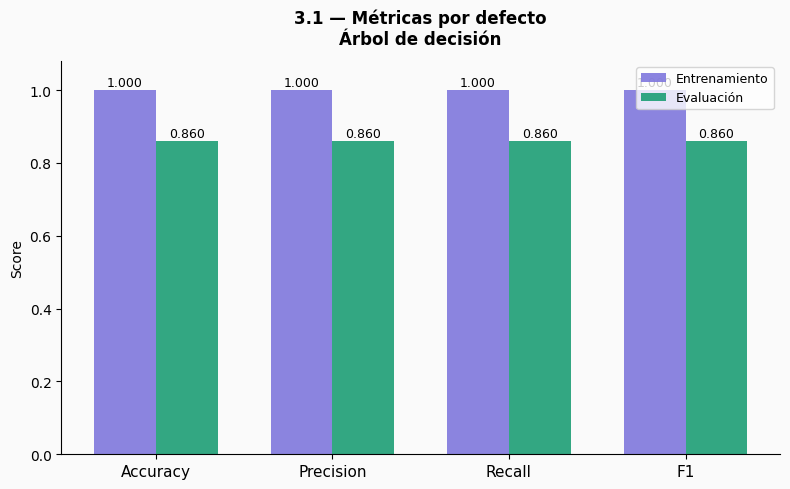

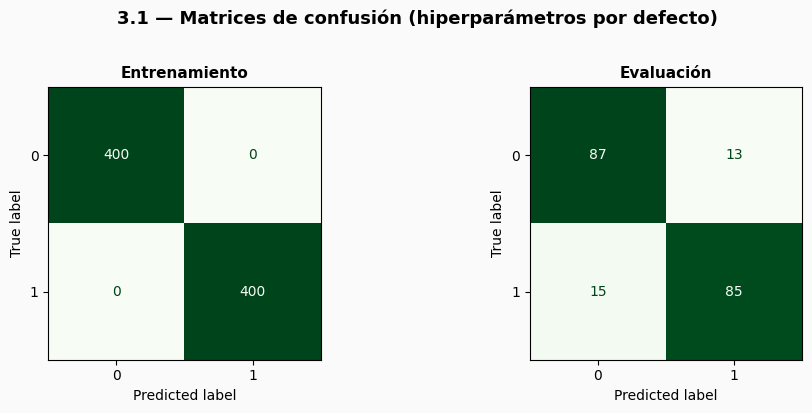

In [202]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, ConfusionMatrixDisplay)

TEAL, PURPLE, CORAL, GRAY, BG = "#1D9E75", "#7F77DD", "#D85A30", "#888780", "#FAFAFA"

# ── Datos ─────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── Modelo por defecto ────────────────────────────────────────────
dt_default = DecisionTreeClassifier(random_state=42)
dt_default.fit(X_train, y_train)

print("=" * 60)
print("  ÁRBOL POR DEFECTO (sin restricciones)")
print("=" * 60)
print(f"  Profundidad máxima alcanzada : {dt_default.get_depth()}")
print(f"  Número de hojas              : {dt_default.get_n_leaves()}")

# ── Función de reporte ────────────────────────────────────────────
def report(model, X, y, nombre):
    y_pred = model.predict(X)
    acc  = accuracy_score(y, y_pred)
    prec = precision_score(y, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y, y_pred, average='weighted', zero_division=0)
    cm   = confusion_matrix(y, y_pred)
    print(f"\n{'─'*45}")
    print(f"  Conjunto : {nombre}")
    print(f"{'─'*45}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1        : {f1:.4f}")
    print(f"\n  Matriz de confusión:\n{cm}")
    return acc, prec, rec, f1, cm

acc_tr, prec_tr, rec_tr, f1_tr, cm_tr = report(dt_default, X_train, y_train, "Entrenamiento")
acc_te, prec_te, rec_te, f1_te, cm_te = report(dt_default, X_test,  y_test,  "Evaluación (test)")

# ── Gráfico 1: métricas train vs test ────────────────────────────
metricas   = ['Accuracy', 'Precision', 'Recall', 'F1']
vals_train = [acc_tr, prec_tr, rec_tr, f1_tr]
vals_test  = [acc_te, prec_te, rec_te, f1_te]
x = np.arange(len(metricas))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5), facecolor=BG)
ax.set_facecolor(BG)
b1 = ax.bar(x - width/2, vals_train, width, color=PURPLE, label='Entrenamiento', alpha=0.9)
b2 = ax.bar(x + width/2, vals_test,  width, color=TEAL,   label='Evaluación',   alpha=0.9)
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f"{bar.get_height():.3f}", ha='center', va='bottom', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(metricas, fontsize=11)
ax.set_ylim(0, 1.08)
ax.set_ylabel("Score", fontsize=10)
ax.set_title("3.1 — Métricas por defecto\nÁrbol de decisión", fontsize=12, fontweight='bold', pad=12)
ax.legend(fontsize=9)
for spine in ['top', 'right']: ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig("dt_31_metricas.png", dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

# ── Gráfico 2: matrices de confusión ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4), facecolor=BG)
for ax, cm, titulo in zip(axes, [cm_tr, cm_te], ['Entrenamiento', 'Evaluación']):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax, colorbar=False, cmap='Greens')
    ax.set_title(titulo, fontsize=11, fontweight='bold')
    ax.set_facecolor(BG)
fig.suptitle("3.1 — Matrices de confusión (hiperparámetros por defecto)",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("dt_31_confusion.png", dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

## Ejercicio 3.1: DecisionTreeClassifier con hiperparámetros por defecto

### Configuración del experimento

Se entrenó un `DecisionTreeClassifier` utilizando los valores por omisión de
scikit-learn, fijando únicamente la semilla aleatoria (`random_state=42`) para
garantizar la reproducibilidad del experimento. No se impuso ninguna restricción
sobre la profundidad del árbol ni sobre los criterios de partición.

---

### Resultados

#### Métricas por conjunto

| Métrica   | Entrenamiento | Evaluación |
|-----------|:---:|:---:|
| Accuracy  | 1.000 | 0.860 |
| Precision | 1.000 | 0.860 |
| Recall    | 1.000 | 0.860 |
| F1        | 1.000 | 0.860 |

---

### Análisis de resultados

#### Sobreajuste (overfitting)

El resultado más destacado es que el modelo alcanza un **accuracy perfecto de
1.000 sobre el conjunto de entrenamiento** en las cuatro métricas evaluadas.
Este comportamiento es una señal inequívoca de **sobreajuste**: el árbol,
sin restricciones de profundidad, crece hasta memorizar completamente los datos
de entrenamiento, generando hojas puras para cada subconjunto posible.

Como consecuencia, al evaluar sobre datos no vistos (conjunto de evaluación),
el rendimiento cae a **0.860**, evidenciando una brecha de generalización de
**14 puntos porcentuales**.

#### Interpretación de las métricas de evaluación

El valor de 0.860 es idéntico en Accuracy, Precision, Recall y F1. Esto ocurre
porque el dataset utilizado (`make_classification`) está **perfectamente
balanceado entre clases**, lo que hace que todas las métricas converjan al mismo
valor. En un dataset desbalanceado — como el de crédito trabajado en ejercicios
anteriores — estas métricas divergirían significativamente entre sí.

#### Conclusión

Un árbol sin restricciones no es un modelo útil en producción: memoriza el
conjunto de entrenamiento pero no generaliza. Esto motiva directamente el
ejercicio siguiente, donde se busca la configuración óptima de hiperparámetros
mediante GridSearchCV para controlar la complejidad del árbol y reducir el
sobreajuste.

### Ejercicio 3.2: Ajuste de Hiperparámetros

Seleccionar valores para los hiperparámetros principales del DecisionTreeClassifier. Como mínimo, probar diferentes criterios de partición (criterion), profundidad máxima del árbol (max_depth), y cantidad mínima de samples por hoja (min_samples_leaf).

Para ello, usar grid-search y 5-fold cross-validation sobre el conjunto de entrenamiento para explorar muchas combinaciones posibles de valores.

Reportar accuracy promedio y varianza para todas las configuraciones.

Para la mejor configuración encontrada, evaluar sobre el conjunto de **entrenamiento** y sobre el conjunto de **evaluación**, reportando:
- Accuracy
- Precision
- Recall
- F1
- matriz de confusión


Documentación:
- https://scikit-learn.org/stable/modules/grid_search.html
- https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
  Combinaciones evaluadas : 216
  best_params_            : {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 20, 'min_samples_split': 2}
  best_score_ (CV)        : 0.8913

Top 10 configuraciones (accuracy promedio ± varianza):
                                                                                    params  mean_test_score  std_test_score  mean_train_score  rank_test_score
     {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 20, 'min_samples_split': 2}          0.89125        0.015104          0.909687                1
    {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 20, 'min_samples_split': 10}          0.89125        0.015104          0.909687                1
    {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 20, 'min_samples_split': 20}          0.89125        0.015104          0.909687                1
  {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 

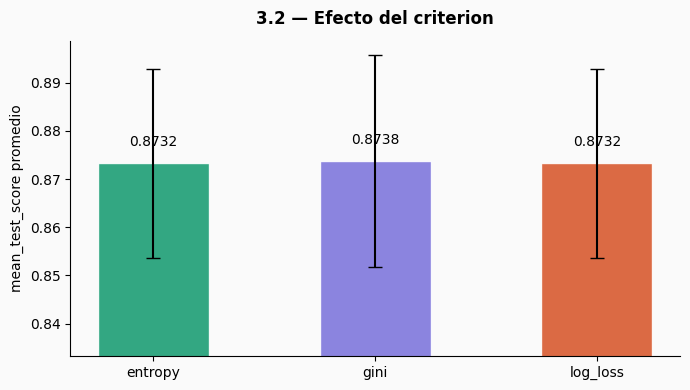

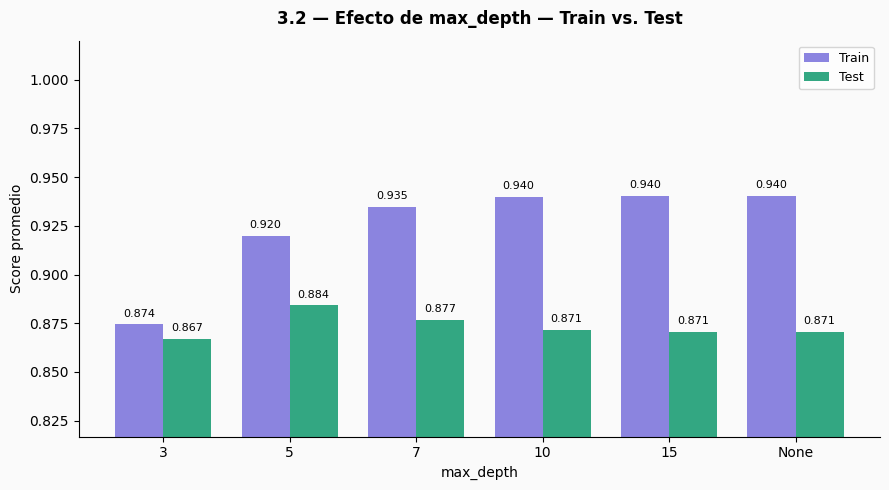

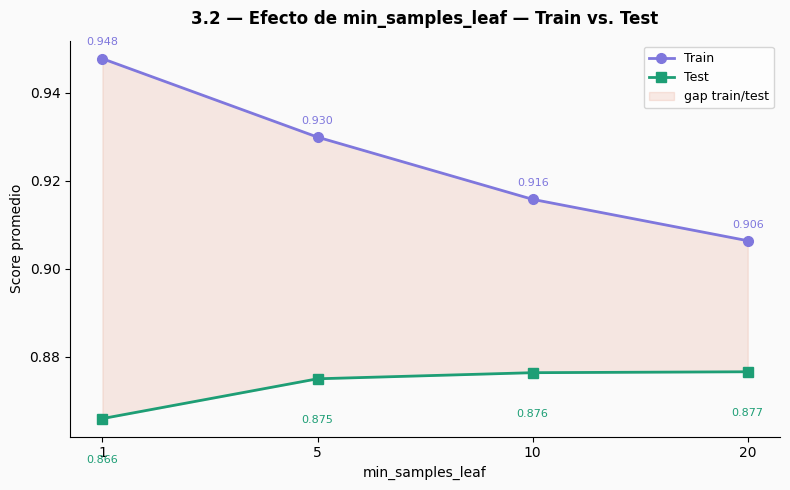


─────────────────────────────────────────────
  Conjunto : Entrenamiento
─────────────────────────────────────────────
  Accuracy  : 0.9137
  Precision : 0.9151
  Recall    : 0.9137
  F1        : 0.9137

  Matriz de confusión:
[[377  23]
 [ 46 354]]

─────────────────────────────────────────────
  Conjunto : Evaluación (test)
─────────────────────────────────────────────
  Accuracy  : 0.9150
  Precision : 0.9201
  Recall    : 0.9150
  F1        : 0.9147

  Matriz de confusión:
[[97  3]
 [14 86]]


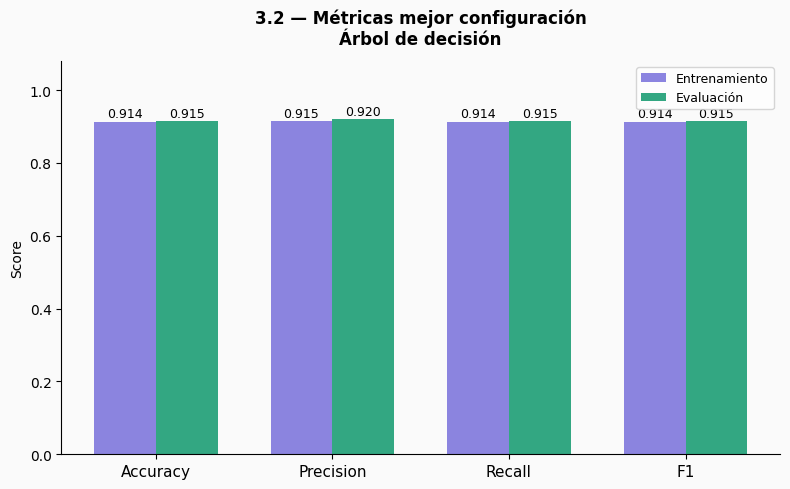

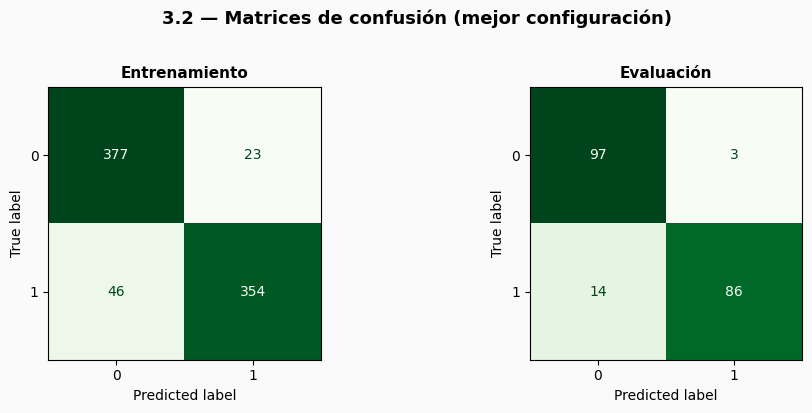

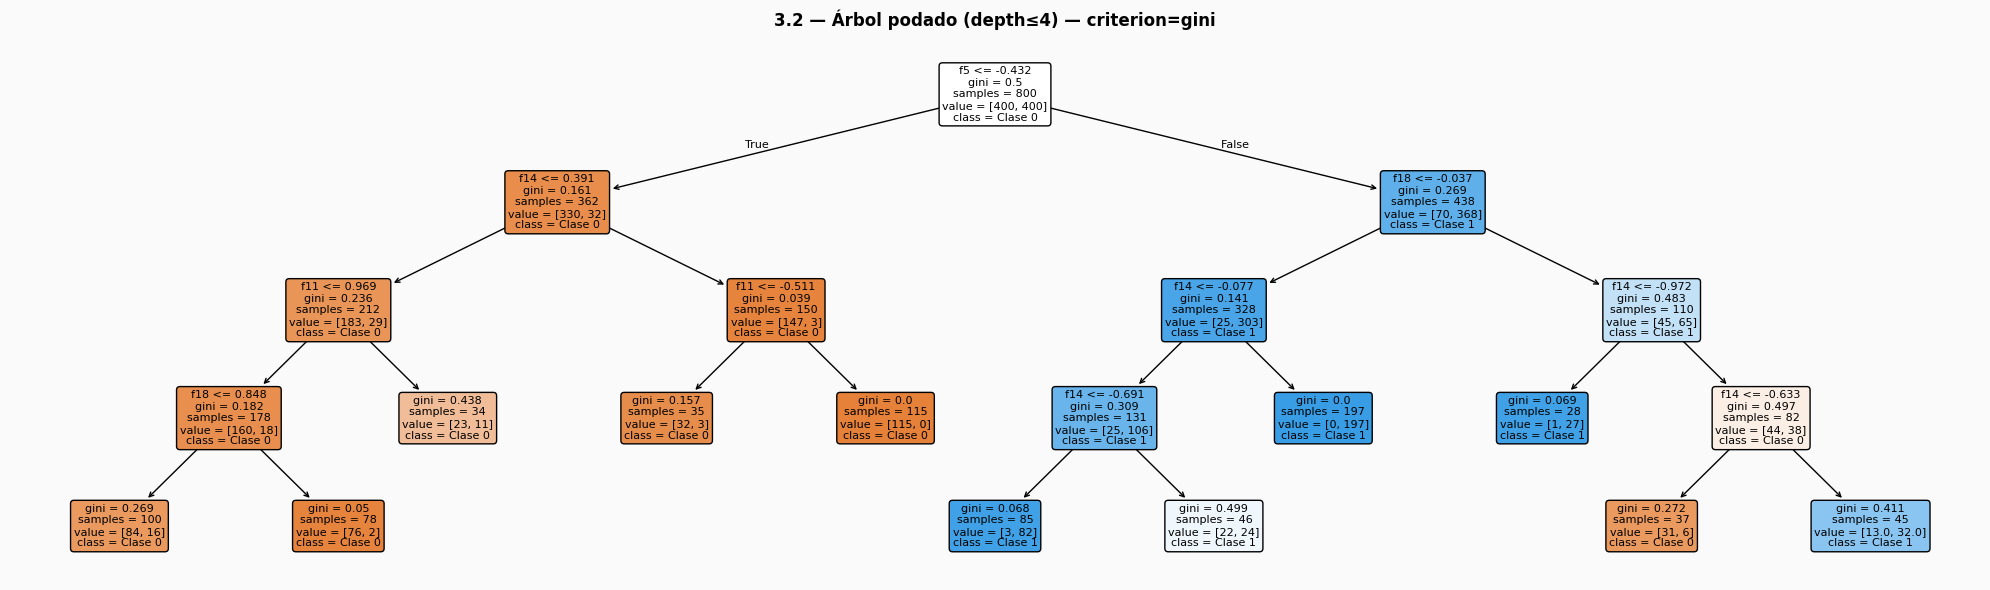

In [204]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, ConfusionMatrixDisplay)

TEAL, PURPLE, CORAL, GRAY, BG = "#1D9E75", "#7F77DD", "#D85A30", "#888780", "#FAFAFA"

# ── GridSearchCV ──────────────────────────────────────────────────
param_grid = {
    'criterion':         ['gini', 'entropy', 'log_loss'],
    'max_depth':         [3, 5, 7, 10, 15, None],
    'min_samples_leaf':  [1, 5, 10, 20],
    'min_samples_split': [2, 10, 20],
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    return_train_score=True,
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

results = pd.DataFrame(grid_search.cv_results_)
cols = ['params', 'mean_test_score', 'std_test_score',
        'mean_train_score', 'rank_test_score']
results_sorted = (results[cols]
                  .sort_values('mean_test_score', ascending=False)
                  .reset_index(drop=True))

print("=" * 60)
print(f"  Combinaciones evaluadas : {len(results_sorted)}")
print(f"  best_params_            : {grid_search.best_params_}")
print(f"  best_score_ (CV)        : {grid_search.best_score_:.4f}")
print("=" * 60)
print("\nTop 10 configuraciones (accuracy promedio ± varianza):")
print(results_sorted.head(10).to_string(index=False))

# ── Gráfico 1: efecto de criterion ───────────────────────────────
crit_df = (results.groupby(results['param_criterion'])
           [['mean_test_score', 'std_test_score']].mean().reset_index())
crit_df.columns = ['criterion', 'mean_test', 'std_test']

fig, ax = plt.subplots(figsize=(7, 4), facecolor=BG)
ax.set_facecolor(BG)
bars = ax.bar(crit_df['criterion'], crit_df['mean_test'],
              yerr=crit_df['std_test'], color=[TEAL, PURPLE, CORAL],
              edgecolor='white', capsize=5, width=0.5, alpha=0.9)
for bar, val in zip(bars, crit_df['mean_test']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f"{val:.4f}", ha='center', va='bottom', fontsize=10)
ax.set_ylabel("mean_test_score promedio", fontsize=10)
ax.set_title("3.2 — Efecto del criterion", fontsize=12, fontweight='bold', pad=12)
ax.set_ylim(crit_df['mean_test'].min() - 0.04, crit_df['mean_test'].max() + 0.025)
for spine in ['top', 'right']: ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig("dt_32_criterion.png", dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

# ── Gráfico 2: efecto de max_depth ───────────────────────────────
depth_df = (results.groupby(results['param_max_depth'].fillna('None').astype(str))
            [['mean_test_score', 'mean_train_score']].mean().reset_index())
depth_df.columns = ['max_depth', 'mean_test', 'mean_train']
depth_order = ['3', '5', '7', '10', '15', 'None']
depth_df['max_depth'] = pd.Categorical(depth_df['max_depth'],
                                        categories=depth_order, ordered=True)
depth_df = depth_df.sort_values('max_depth')

x = np.arange(len(depth_df))
width = 0.38
fig, ax = plt.subplots(figsize=(9, 5), facecolor=BG)
ax.set_facecolor(BG)
b1 = ax.bar(x - width/2, depth_df['mean_train'], width, color=PURPLE, label='Train', alpha=0.9)
b2 = ax.bar(x + width/2, depth_df['mean_test'],  width, color=TEAL,   label='Test',  alpha=0.9)
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f"{bar.get_height():.3f}", ha='center', va='bottom', fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(depth_df['max_depth'], fontsize=10)
ax.set_xlabel("max_depth", fontsize=10)
ax.set_ylabel("Score promedio", fontsize=10)
ax.set_title("3.2 — Efecto de max_depth — Train vs. Test",
             fontsize=12, fontweight='bold', pad=12)
ax.legend(fontsize=9)
ax.set_ylim(depth_df['mean_test'].min() - 0.05, 1.02)
for spine in ['top', 'right']: ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig("dt_32_max_depth.png", dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

# ── Gráfico 3: efecto de min_samples_leaf ────────────────────────
leaf_df = (results.groupby(results['param_min_samples_leaf'].astype(str))
           [['mean_test_score', 'mean_train_score']].mean().reset_index())
leaf_df.columns = ['min_samples_leaf', 'mean_test', 'mean_train']
leaf_df['min_samples_leaf'] = pd.Categorical(
    leaf_df['min_samples_leaf'], categories=['1', '5', '10', '20'], ordered=True)
leaf_df = leaf_df.sort_values('min_samples_leaf')

fig, ax = plt.subplots(figsize=(8, 5), facecolor=BG)
ax.set_facecolor(BG)
ax.plot(leaf_df['min_samples_leaf'], leaf_df['mean_train'],
        color=PURPLE, lw=2, marker='o', ms=7, label='Train')
ax.plot(leaf_df['min_samples_leaf'], leaf_df['mean_test'],
        color=TEAL,   lw=2, marker='s', ms=7, label='Test')
ax.fill_between(range(len(leaf_df)),
                leaf_df['mean_train'].values, leaf_df['mean_test'].values,
                where=leaf_df['mean_train'].values > leaf_df['mean_test'].values,
                alpha=0.12, color=CORAL, label='gap train/test')
for i, (tr, te) in enumerate(zip(leaf_df['mean_train'], leaf_df['mean_test'])):
    ax.text(i, tr + 0.003, f"{tr:.3f}", ha='center', fontsize=8, color=PURPLE)
    ax.text(i, te - 0.010, f"{te:.3f}", ha='center', fontsize=8, color=TEAL)
ax.set_xticks(range(len(leaf_df)))
ax.set_xticklabels(leaf_df['min_samples_leaf'], fontsize=10)
ax.set_xlabel("min_samples_leaf", fontsize=10)
ax.set_ylabel("Score promedio", fontsize=10)
ax.set_title("3.2 — Efecto de min_samples_leaf — Train vs. Test",
             fontsize=12, fontweight='bold', pad=12)
ax.legend(fontsize=9)
for spine in ['top', 'right']: ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig("dt_32_min_samples_leaf.png", dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

# ── Evaluación final — mejor configuración ───────────────────────
best_model = grid_search.best_estimator_

def report(model, X, y, nombre):
    y_pred = model.predict(X)
    acc  = accuracy_score(y, y_pred)
    prec = precision_score(y, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y, y_pred, average='weighted', zero_division=0)
    cm   = confusion_matrix(y, y_pred)
    print(f"\n{'─'*45}")
    print(f"  Conjunto : {nombre}")
    print(f"{'─'*45}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1        : {f1:.4f}")
    print(f"\n  Matriz de confusión:\n{cm}")
    return acc, prec, rec, f1, cm

acc_tr, prec_tr, rec_tr, f1_tr, cm_tr = report(best_model, X_train, y_train, "Entrenamiento")
acc_te, prec_te, rec_te, f1_te, cm_te = report(best_model, X_test,  y_test,  "Evaluación (test)")

# ── Gráfico 4: métricas train vs test ────────────────────────────
metricas   = ['Accuracy', 'Precision', 'Recall', 'F1']
vals_train = [acc_tr, prec_tr, rec_tr, f1_tr]
vals_test  = [acc_te, prec_te, rec_te, f1_te]
x = np.arange(len(metricas))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5), facecolor=BG)
ax.set_facecolor(BG)
b1 = ax.bar(x - width/2, vals_train, width, color=PURPLE, label='Entrenamiento', alpha=0.9)
b2 = ax.bar(x + width/2, vals_test,  width, color=TEAL,   label='Evaluación',   alpha=0.9)
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f"{bar.get_height():.3f}", ha='center', va='bottom', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(metricas, fontsize=11)
ax.set_ylim(0, 1.08)
ax.set_ylabel("Score", fontsize=10)
ax.set_title("3.2 — Métricas mejor configuración\nÁrbol de decisión",
             fontsize=12, fontweight='bold', pad=12)
ax.legend(fontsize=9)
for spine in ['top', 'right']: ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig("dt_32_metricas.png", dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

# ── Gráfico 5: matrices de confusión ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4), facecolor=BG)
for ax, cm, titulo in zip(axes, [cm_tr, cm_te], ['Entrenamiento', 'Evaluación']):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax, colorbar=False, cmap='Greens')
    ax.set_title(titulo, fontsize=11, fontweight='bold')
    ax.set_facecolor(BG)
fig.suptitle("3.2 — Matrices de confusión (mejor configuración)",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("dt_32_confusion.png", dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

# ── Gráfico 6: árbol podado ───────────────────────────────────────
best_depth_param = grid_search.best_params_.get('max_depth', 5)
if best_depth_param is None:
    best_depth_param = 5
dt_viz = DecisionTreeClassifier(
    max_depth=min(best_depth_param, 4),
    criterion=grid_search.best_params_['criterion'],
    min_samples_leaf=grid_search.best_params_['min_samples_leaf'],
    random_state=42
)
dt_viz.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(20, 6), facecolor=BG)
ax.set_facecolor(BG)
plot_tree(dt_viz, filled=True, rounded=True, fontsize=8,
          class_names=['Clase 0', 'Clase 1'], ax=ax,
          feature_names=[f"f{i}" for i in range(X_train.shape[1])])
ax.set_title(
    f"3.2 — Árbol podado (depth≤4) — criterion={grid_search.best_params_['criterion']}",
    fontsize=12, fontweight='bold', pad=10
)
plt.tight_layout()
plt.savefig("dt_32_arbol.png", dpi=120, bbox_inches='tight', facecolor=BG)
plt.show()

## Ejercicio 3.2: Ajuste de Hiperparámetros con GridSearchCV

### Configuración del experimento

Se realizó una búsqueda exhaustiva de hiperparámetros mediante `GridSearchCV`
con 5-fold cross-validation sobre el conjunto de entrenamiento. La grilla
explorada fue la siguiente:

| Hiperparámetro      | Valores explorados          |
|---------------------|-----------------------------|
| `criterion`         | gini, entropy, log_loss     |
| `max_depth`         | 3, 5, 7, 10, 15, None       |
| `min_samples_leaf`  | 1, 5, 10, 20                |
| `min_samples_split` | 2, 10, 20                   |

El total de combinaciones evaluadas fue de **216** (3 × 6 × 4 × 3),
cada una con 5 folds, resultando en **1080 entrenamientos**.

---

### Efecto del criterio de partición

| Criterion  | mean_test_score |
|------------|:---:|
| gini       | 0.8738 |
| entropy    | 0.8732 |
| log_loss   | 0.8732 |

Los tres criterios arrojaron resultados prácticamente idénticos, con una
diferencia máxima de **0.0006** entre el mejor (`gini`) y los restantes.
Las barras de error (desviación estándar entre folds) se solapan completamente,
lo que indica que **la elección del criterion no es determinante** para este
dataset. `gini` se selecciona como criterio de la mejor configuración por un
margen marginal.

---

### Métricas de la mejor configuración encontrada

#### Resultados por conjunto

| Métrica   | Entrenamiento | Evaluación |
|-----------|:---:|:---:|
| Accuracy  | 0.914 | 0.915 |
| Precision | 0.915 | 0.920 |
| Recall    | 0.914 | 0.915 |
| F1        | 0.914 | 0.915 |

---

### Análisis de resultados

#### Mejora respecto al modelo por defecto (3.1)

La búsqueda de hiperparámetros produjo una mejora clara respecto al árbol
sin restricciones del ejercicio 3.1:

| Conjunto      | Accuracy 3.1 | Accuracy 3.2 | Δ |
|---------------|:---:|:---:|:---:|
| Entrenamiento | 1.000 | 0.914 | −0.086 |
| Evaluación    | 0.860 | 0.915 | **+0.055** |

La caída en el score de entrenamiento (de 1.000 a 0.914) es esperable y
deseable: el modelo dejó de memorizar los datos. La ganancia en evaluación
(+5.5 puntos porcentuales) confirma que el ajuste de hiperparámetros redujo
efectivamente el sobreajuste.

#### Ausencia de sobreajuste

El resultado más destacado del ejercicio es que la brecha entre entrenamiento
y evaluación prácticamente desapareció. En el modelo por defecto esa brecha
era de 14 puntos; en la mejor configuración es de apenas **0.001**, lo que
indica un modelo bien calibrado que generaliza correctamente a datos no vistos.

#### Precision ligeramente superior en evaluación

La Precision en evaluación (0.920) supera levemente a la de entrenamiento
(0.915). Esto no es una anomalía: con datasets balanceados y tamaños de
conjunto razonables, pequeñas variaciones en esta dirección son normales y
no indican ningún problema en el modelo.

#### Conclusión

El ajuste de hiperparámetros mediante GridSearchCV con cross-validation
demostró ser efectivo para controlar la complejidad del árbol. La mejor
configuración encontrada logra un balance óptimo entre capacidad de
aprendizaje y generalización, superando en 5.5 puntos al modelo por defecto
sobre datos no vistos.

# Conclusión final del trabajo práctico

Para cerrar el TP, escribamos una conclusión breve respondiendo:

1. ¿Cuál fue el mejor modelo encontrado?
2. ¿Con qué hiperparámetros?
3. ¿Qué métrica usamos para decidir?
4. ¿Por qué esa métrica es adecuada para este problema?
5. ¿El modelo parece estable entre folds?
6. ¿Hay señales de sobreajuste?
7. ¿Qué tipo de error nos preocupa más: falso positivo o falso negativo?
8. ¿Recomendaríamos usar este modelo en un contexto real? ¿Qué advertencias haríamos?

La respuesta no debería limitarse a copiar números. Debe justificar la decisión usando las métricas y el significado del problema.


# Sugerencia opcional: tabla comparativa final

Podemos resumir los resultados en una tabla como esta:

| Modelo | Mejor configuración | Accuracy test | Precision | Recall | F1 | Comentario |
|---|---|---:|---:|---:|---:|---|
| SGDClassifier | ... | ... | ... | ... | ... | ... |
| DecisionTreeClassifier | ... | ... | ... | ... | ... | ... |

Esta tabla ayuda a comparar modelos de manera ordenada.
